In [10]:
import h5py
import numpy as np
import gvar as gv
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma
import inspect
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ---------------------------------------------------------
# 1. Jackknife Statistics Helper
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    # switch to scientific if very small/big
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        m_str = f"{mean:.2e}"           # e.g. "2.86e-08"
        mant, exp = m_str.split("e")
        ndec = len(mant.split(".")[1])  # digits in mantissa
        err_int = int(round(err / 10**int(exp) * 10**ndec))
        return f"{mant}({err_int})e{int(exp)}"
    else:
        ndec = 4                        # choose 4 decimal places
        m_str = f"{mean:.{ndec}f}"      # e.g. "0.4721"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int:0{ndec}d})"

# ---------------------------------------------------------
# 2. Data Loading & Filtering Helper
# ---------------------------------------------------------
def load_and_filter_data(filepath, bminForFit, etamin, etamax):
    """Loads HDF5 data and applies kinematic cuts."""
    with h5py.File(filepath, "r") as f:
        raw_data = f["Dataset1"][:]
        
    kin = raw_data[:, 0:3]
    samples = raw_data[:, 3:]
    
    eta = kin[:, 0]
    bL  = kin[:, 1]
    bT  = kin[:, 2]
    
    # Calculate b = sqrt(bL^2 + bT^2)
    b_mag = np.sqrt(bL**2 + bT**2)
    
    # Create a boolean mask for our cuts
    mask = (eta >= etamin) & (eta <= etamax) & (b_mag >= bminForFit)
    
    # Return only the rows that passed the cuts
    return kin[mask], samples[mask]


def load_and_filter_data_rm_0_bL(filepath, bminForFit, etamin, etamax):
    """Loads HDF5 data and applies kinematic cuts."""
    with h5py.File(filepath, "r") as f:
        raw_data = f["Dataset1"][:]
        
    kin = raw_data[:, 0:3]
    samples = raw_data[:, 3:]
    
    eta = kin[:, 0]
    bL  = kin[:, 1]
    bT  = kin[:, 2]
    
    # Calculate b = sqrt(bL^2 + bT^2)
    b_mag = np.sqrt(bL**2 + bT**2)
    
    # Create a boolean mask for our cuts
    mask = (eta >= etamin) & (eta <= etamax) & (b_mag >= bminForFit) & (bL != 0)
    
    # Return only the rows that passed the cuts
    return kin[mask], samples[mask]


def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, g, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.tanh(g*bL) * gv.exp(-f * eta) / denom


def fcn(x, p):
    # 1. Unpack the kinematic arrays from the dictionary x
    kin_re = x['Re']
    kin_im = x['Im']
    
    eta_re, bL_re, bT_re = kin_re[:, 0], kin_re[:, 1], kin_re[:, 2]
    eta_im, bL_im, bT_im = kin_im[:, 0], kin_im[:, 1], kin_im[:, 2]

    # Shared parameter
    f = p['f']
    
    # Real-specific parameters
    val_re = ReA2B(eta_re, bL_re, bT_re, p['a_re'], p['c_re'], p['d_re'], f, p['k1_re'], p['k2_re'], p['j_re'])
    
    # Imaginary-specific parameters
    val_im = ImA2B(eta_im, bL_im, bT_im, p['a_im'], p['c_im'], p['d_im'], p['g_im'], f, p['k1_im'], p['k2_im'], p['j_im'])
    
    return {'Re': val_re, 'Im': val_im}
    
# ---------------------------------------------------------
# 3. Main Simultaneous Fitting Function
# ---------------------------------------------------------
def FitSimultaneousA2B(PL, bminForFit, etamin, etamax):
    print(f"Simultaneous Fit (ReA2B & ImA2B) : PL={PL}, b_min>={bminForFit}, eta in [{etamin}, {etamax}] ---")
    print("\n--- Fit Functions ---")
    print(inspect.getsource(ReA2B))
    print(inspect.getsource(ImA2B))
    print("---------------------\n")
    
    # 1. Construct file paths (Update the base path if needed)
    base_path = "/pscratch/sd/h/hari_8/TMD_fit/h5data/"
    file_re = f"{base_path}/ReA2B_PL{PL}_jackknife_data.h5"
    file_im = f"{base_path}/ImA2B_PL{PL}_jackknife_data.h5"
    
    # 2. Load and Filter Data
    kin_re, jk_re = load_and_filter_data(file_re, bminForFit, etamin, etamax)
    kin_im, jk_im = load_and_filter_data_rm_0_bL(file_im, bminForFit, etamin, etamax)
    
    N_re = jk_re.shape[0]
    N_im = jk_im.shape[0]
    N_samples = jk_re.shape[1]
    
    print(f"Re A2B points: {N_re}, Im A2B points: {N_im}")

    # 3. Calculate the Full Jackknife Covariance Matrix
    combined_jk = np.vstack([jk_re, jk_im])
    mean_data = np.mean(combined_jk, axis=1)
    diff = combined_jk - mean_data[:, None]
    cov_matrix = ((N_samples - 1) / N_samples) * (diff @ diff.T)
    print(f"Covariance Matrix size: {cov_matrix.shape}")


    # ---------------------------------------------------------
    # Set up Priors
    # ---------------------------------------------------------
    current_prior = {
     'k1_re'  : gv.gvar(-5.83, 0.05),
     'k2_re'  : gv.gvar(-4.86, 0.05),
     'k1_im'  : gv.gvar(-5.83, 0.05),
     'k2_im'  : gv.gvar(-4.86, 0.05),
     'f'   : gv.gvar(0.50,  0.05),
     'a_re' : gv.gvar(4.01,  0.05),
     'c_re' : gv.gvar(0.60,  0.05),
     'd_re' : gv.gvar(0.094, 0.05),
     'j_re' : gv.gvar(2.06,  0.05),
     'a_im' : gv.gvar(0.100, 0.05),
     'c_im' : gv.gvar(0.60,  0.05),
     'd_im' : gv.gvar(0.094, 0.05),
     'g_im' : gv.gvar(0.2, 0.05),
     'j_im' : gv.gvar(2.06,  0.05),
    }


    x_dict = {'Re': kin_re, 'Im': kin_im}
    param_names = ['k1_re','k2_re','k1_im','k2_im','f','a_re','c_re','d_re','j_re','a_im','c_im','d_im','g_im','j_im']
    fitted_params = {key: [] for key in param_names}
    
    # We will also track chi-square per degree of freedom
    chi2_dof_list = []

    for i in tqdm(range(N_samples)):
        y_sample_i = combined_jk[:, i]
        y_gvar_i = gv.gvar(y_sample_i, cov_matrix)
        
        y_dict = {
            'Re': y_gvar_i[:N_re],
            'Im': y_gvar_i[N_re:]
        }
        
        fit = lsqfit.nonlinear_fit(data=(x_dict, y_dict), prior=current_prior, fcn=fcn, debug=False)
        
        for key in fitted_params:
            fitted_params[key].append(fit.pmean[key])
            
        #chi2_dof_list.append(fit.chi2 / (fit.dof - len(param_names)))
        dof = (N_re + N_im) - len(param_names)
        chi2_dof_list.append(fit.chi2 / dof)

    # 7. Apply Jackknife and Print Results
    print("\n--- Final Extracted Parameters ---")
    for key in fitted_params:
        mean_val, err_val = Jackknife(fitted_params[key])
        print(f"{key:>5} = {fmt_err(mean_val, err_val)}")
        
    mean_chi2, err_chi2 = Jackknife(chi2_dof_list)
    print(f"\n chi^2/dof : {fmt_err(mean_chi2, err_chi2)}\n")
    
    # Return the dictionary of jackknifed parameter arrays in case you want to plot them later
    return fitted_params


# ---------------------------------------------------------
# Plotting Function
# ---------------------------------------------------------
def plot_fourier_transforms(fitted_params, b2, PL, num_points=200):
    # 1. Setup x-axis (avoid exactly 0 to prevent division by zero in Bessel/powers)
    x_vals = np.linspace(-1, 1, num_points)
    
    # 2. Extract parameters as NumPy arrays
    a_re = np.array(fitted_params['a_re'])
    c_re = np.array(fitted_params['c_re']) / (PL**2)
    d_re = 1.0 + np.array(fitted_params['d_re']) * b2  
    j_re = np.array(fitted_params['j_re'])

    a_im = np.array(fitted_params['a_im']) / PL
    c_im = np.array(fitted_params['c_im']) / (PL**2)
    d_im = 1.0 + np.array(fitted_params['d_im']) * b2
    j_im = np.array(fitted_params['j_im'])

    # Prepare lists to store the jackknife results for plotting
    re_mean, re_err = [], []
    im_mean, im_err = [], []
    full_mean, full_err = [], []

    print("Evaluating Fourier transforms and applying Jackknife...")
    
    # 3. Loop over each x value and apply your Jackknife function
    for x in x_vals:
        abs_x = np.abs(x)

        # --- Evaluate Real Part for all ~2900 samples at this x ---
        cd_R = c_re / d_re
        term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
        term2_R = abs_x**(-0.5 + j_re)
        bessel_R = kv(0.5 - j_re, abs_x / np.sqrt(cd_R))
        
        re_evals_at_x = term1_R * term2_R * bessel_R
        
        # Apply your Jackknife function
        m_re, e_re = Jackknife(re_evals_at_x)
        re_mean.append(m_re)
        re_err.append(e_re)

        # --- Evaluate Imaginary Part for all ~2900 samples at this x ---
        cd_I = c_im / d_im
        term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
        term2_I = x * abs_x**(-1.5 + j_im)
        bessel_I = kv(1.5 - j_im, np.sqrt(d_im / c_im) * abs_x)
        
        im_evals_at_x = term1_I * term2_I * bessel_I
        
        # Apply your Jackknife function
        m_im, e_im = Jackknife(im_evals_at_x)
        im_mean.append(m_im)
        im_err.append(e_im)

        m_full, e_full = Jackknife(re_evals_at_x-im_evals_at_x)
        full_mean.append(m_full)
        full_err.append(e_full)

    # Convert results to arrays for easier plotting
    re_mean, re_err = np.array(re_mean), np.array(re_err)
    im_mean, im_err = np.array(im_mean), np.array(im_err)
    full_mean, full_err = np.array(full_mean), np.array(full_err)

    # 4. Plotting
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

    # Real Plot
    ax1.plot(x_vals, re_mean, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, re_mean - re_err, re_mean + re_err, color='blue', alpha=0.3, label='Jackknife Error Band')
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($P_L$={PL}, $b^2$={b2})')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$\\tilde{{A}}_{{2B}}^{{Re}}$')
    #ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Imaginary Plot
    ax2.plot(x_vals, im_mean, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, im_mean - im_err, im_mean + im_err, color='red', alpha=0.3, label='Jackknife Error Band')
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($P_L$={PL}, $b^2$={b2})')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    #ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)


    ax3.plot(x_vals, full_mean, color='green', label='A2B Mean')
    ax3.fill_between(x_vals, full_mean - full_err, full_mean + full_err, color='green', alpha=0.3, label='Jackknife Error Band')
    ax3.set_title(f'$\\tilde{{A}}_{{2B}}$ ($P_L$={PL}, $b^2$={b2}) = $\\tilde{{A}}_{{2B}}^{{Re}}+i(i\\tilde{{A}}_{{2B}}^{{Im}})$')
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$\\tilde{{A}}_{{2B}}$')
    #ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    param_keys_str = "-".join(fitted_params.keys())
    file_name = f"/pscratch/sd/h/hari_8/TMD_fit/jupyter/SimulFitCovMatrix-A2B-FT-{param_keys_str}.pdf"
    
    plt.savefig(file_name, format='pdf', bbox_inches='tight', dpi=1500)
    plt.show()

    return fig, (ax1, ax2, ax3)

In [14]:
from scipy.integrate import simpson

def plot_fourier_transforms(fitted_params, b2, PL, num_points=200):
    # 1. Setup x-axis (avoid exactly 0 to prevent division by zero in Bessel/powers)
    # Using small offset from 0 for numerical stability in the real part
    x_vals = np.linspace(-1, 1, num_points)
    x_vals[np.abs(x_vals) < 1e-10] = 1e-10 
    
    # 2. Extract parameters as NumPy arrays
    a_re = np.array(fitted_params['a_re'])
    c_re = np.array(fitted_params['c_re']) / (PL**2)
    d_re = 1.0 + np.array(fitted_params['d_re']) * b2  
    j_re = np.array(fitted_params['j_re'])

    a_im = np.array(fitted_params['a_im']) / PL
    c_im = np.array(fitted_params['c_im']) / (PL**2)
    d_im = 1.0 + np.array(fitted_params['d_im']) * b2
    j_im = np.array(fitted_params['j_im'])
    
    # NEW: Extract g_im for the tanh transition scale
    g_im = np.array(fitted_params['g_im'])

    # Prepare lists to store the jackknife results for plotting
    re_mean, re_err = [], []
    im_mean, im_err = [], []
    full_mean, full_err = [], []

    print("Evaluating Fourier transforms and applying Jackknife...")
    
    # --- SETUP VECTORIZED NUMERICAL INTEGRATION FOR IMAGINARY PART ---
    # Create a dense grid in bL space for integration (0 to 100 fm is plenty 
    # to capture the tail since the denominator decays extremely rapidly)
    bL_grid = np.linspace(0, 100, 10000)
    
    # Reshape imaginary parameters to (N_samples, 1) so they can broadcast 
    # across the bL_grid of shape (5000,)
    a_im_v = a_im[:, np.newaxis]
    c_im_v = c_im[:, np.newaxis]
    d_im_v = d_im[:, np.newaxis]
    j_im_v = j_im[:, np.newaxis]
    g_im_v = g_im[:, np.newaxis]
    
    # Precompute the coordinate-space ImA2B function for all samples and all grid points
    # This shape will be (N_samples, 5000)
    spatial_ImA2B = a_im_v * np.tanh(g_im_v * bL_grid) / (c_im_v * bL_grid**2 + d_im_v)**j_im_v
    
    # 3. Loop over each x value to evaluate the FT
    for x in x_vals:
        abs_x = np.abs(x)

        # --- Evaluate Real Part (Analytical) ---
        cd_R = c_re / d_re
        term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
        term2_R = abs_x**(-0.5 + j_re)
        bessel_R = kv(0.5 - j_re, abs_x / np.sqrt(cd_R))
        
        re_evals_at_x = term1_R * term2_R * bessel_R
        
        m_re, e_re = Jackknife(re_evals_at_x)
        re_mean.append(m_re)
        re_err.append(e_re)

        # --- Evaluate Imaginary Part (Numerical) ---
        # The Fourier Transform of an odd function f(b_L) is i * 2 * \int_0^\infty f(b_L) sin(x*b_L) db_L
        # Since we are plotting i \tilde{A}_2B^Im, we just compute the real integral: 2 * \int sin(...)
        
        # Multiply the spatial function by the sine term for this specific x
        integrand = spatial_ImA2B * np.sin(x * bL_grid)
        
        # Integrate along the bL_grid axis (axis=1) using the trapezoidal rule
        im_evals_at_x = np.sqrt(2/np.pi) * simpson(y=integrand, x=bL_grid, axis=1)
        
        m_im, e_im = Jackknife(im_evals_at_x)
        im_mean.append(m_im)
        im_err.append(e_im)

        # --- Evaluate Full T-Even Distribution ---
        m_full, e_full = Jackknife(re_evals_at_x - im_evals_at_x)
        full_mean.append(m_full)
        full_err.append(e_full)

    # Convert results to arrays for easier plotting
    re_mean, re_err = np.array(re_mean), np.array(re_err)
    im_mean, im_err = np.array(im_mean), np.array(im_err)
    full_mean, full_err = np.array(full_mean), np.array(full_err)

    # 4. Plotting
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

    # Real Plot
    ax1.plot(x_vals, re_mean, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, re_mean - re_err, re_mean + re_err, color='blue', alpha=0.3, label='Jackknife Error Band')
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($P_L$={PL}, $b^2$={b2})')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$\\tilde{{A}}_{{2B}}^{{Re}}$')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Imaginary Plot
    ax2.plot(x_vals, im_mean, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, im_mean - im_err, im_mean + im_err, color='red', alpha=0.3, label='Jackknife Error Band')
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($P_L$={PL}, $b^2$={b2})')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Full Plot
    ax3.plot(x_vals, full_mean, color='green', label='A2B Mean')
    ax3.fill_between(x_vals, full_mean - full_err, full_mean + full_err, color='green', alpha=0.3, label='Jackknife Error Band')
    ax3.set_title(f'$\\tilde{{A}}_{{2B}}$ ($P_L$={PL}, $b^2$={b2}) = $\\tilde{{A}}_{{2B}}^{{Re}}+i(i\\tilde{{A}}_{{2B}}^{{Im}})$')
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$\\tilde{{A}}_{{2B}}$')
    ax3.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    param_keys_str = "-".join(fitted_params.keys())
    file_name = f"/pscratch/sd/h/hari_8/TMD_fit/jupyter/SimulFitCovMatrix-A2B-FT-{param_keys_str}.pdf"
    
    plt.savefig(file_name, format='pdf', bbox_inches='tight', dpi=1500)
    plt.show()

    return fig, (ax1, ax2, ax3)

In [6]:
results_4 = FitSimultaneousA2B(PL=-1, bminForFit=3, etamin=6, etamax=10)

Simultaneous Fit (ReA2B & ImA2B) : PL=-1, b_min>=3, eta in [6, 10] ---

--- Fit Functions ---
def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, g, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.tanh(g*bL) * gv.exp(-f * eta) / denom

---------------------

Re A2B points: 225, Im A2B points: 175
Covariance Matrix size: (400, 400)


  0%|          | 0/2903 [00:00<?, ?it/s]


--- Final Extracted Parameters ---
k1_re = -5.7961(0111)
k2_re = -4.8857(0086)
k1_im = -5.8712(0114)
k2_im = -4.8918(0105)
    f = 0.4717(0044)
 a_re = 3.8654(0100)
 c_re = 0.6445(0138)
 d_re = 0.1589(0065)
 j_re = 1.6620(0242)
 a_im = 0.2980(0144)
 c_im = 0.5739(0108)
 d_im = 0.0323(0030)
 g_im = 0.2884(0116)
 j_im = 2.0524(0062)

 chi^2/dof : 2.0683(1361)



Evaluating Fourier transforms and applying Jackknife...


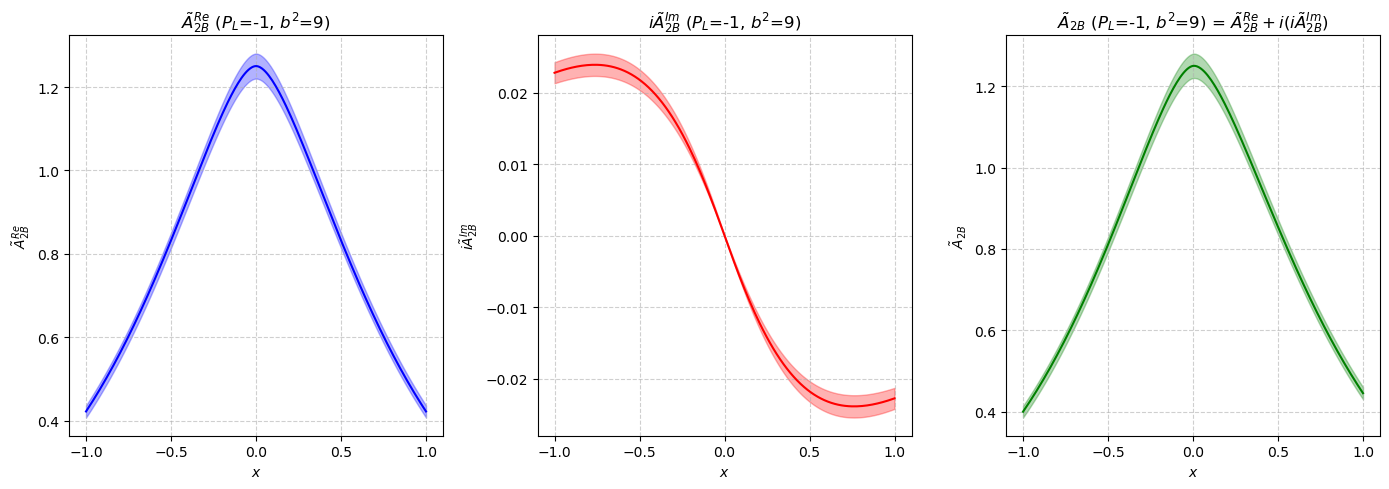

In [15]:
fig4, axes4 = plot_fourier_transforms(results_4, b2=9, PL=-1)

Evaluating Fourier transforms and applying Jackknife...


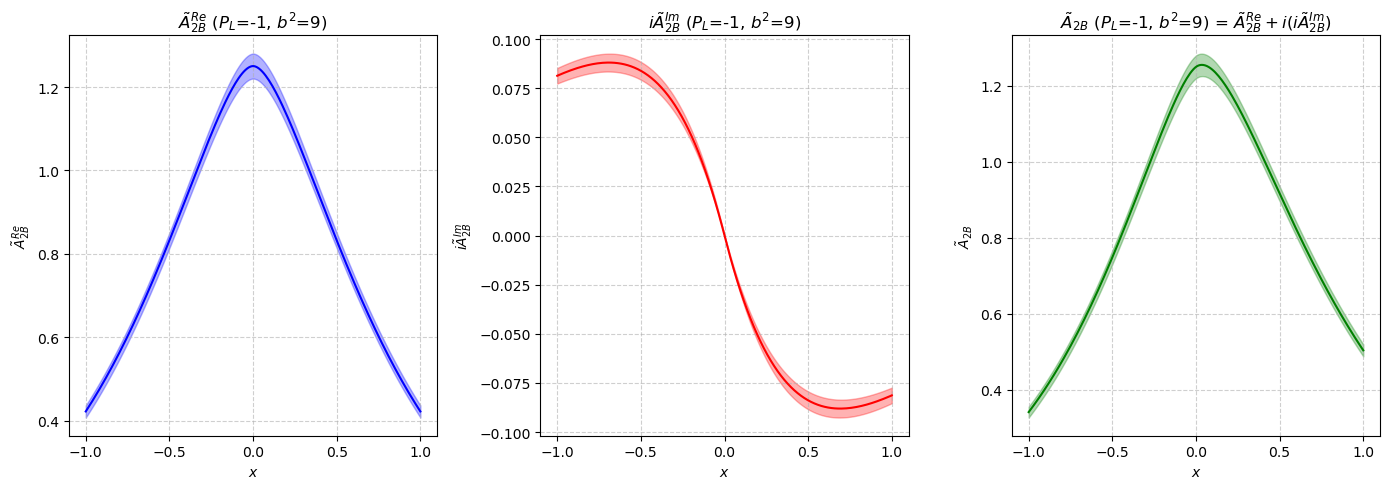

In [11]:
fig4, axes4 = plot_fourier_transforms(results_4, b2=9, PL=-1)

In [6]:
from scipy.integrate import simpson
import h5py
import numpy as np
import gvar as gv
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma
import inspect
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ---------------------------------------------------------
# 1. Jackknife Statistics Helper
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    # switch to scientific if very small/big
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        m_str = f"{mean:.2e}"           # e.g. "2.86e-08"
        mant, exp = m_str.split("e")
        ndec = len(mant.split(".")[1])  # digits in mantissa
        err_int = int(round(err / 10**int(exp) * 10**ndec))
        return f"{mant}({err_int})e{int(exp)}"
    else:
        ndec = 4                        # choose 4 decimal places
        m_str = f"{mean:.{ndec}f}"      # e.g. "0.4721"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int:0{ndec}d})"

# ---------------------------------------------------------
# 2. Data Loading & Filtering Helper
# ---------------------------------------------------------
def load_and_filter_data(filepath, bminForFit, etamin, etamax):
    """Loads HDF5 data and applies kinematic cuts."""
    with h5py.File(filepath, "r") as f:
        raw_data = f["Dataset1"][:]
        
    kin = raw_data[:, 0:3]
    samples = raw_data[:, 3:]
    
    eta = kin[:, 0]
    bL  = kin[:, 1]
    bT  = kin[:, 2]
    
    # Calculate b = sqrt(bL^2 + bT^2)
    b_mag = np.sqrt(bL**2 + bT**2)
    
    # Create a boolean mask for our cuts
    mask = (eta >= etamin) & (eta <= etamax) & (b_mag >= bminForFit)
    
    # Return only the rows that passed the cuts
    return kin[mask], samples[mask]


def load_and_filter_data_rm_0_bL(filepath, bminForFit, etamin, etamax):
    """Loads HDF5 data and applies kinematic cuts."""
    with h5py.File(filepath, "r") as f:
        raw_data = f["Dataset1"][:]
        
    kin = raw_data[:, 0:3]
    samples = raw_data[:, 3:]
    
    eta = kin[:, 0]
    bL  = kin[:, 1]
    bT  = kin[:, 2]
    
    # Calculate b = sqrt(bL^2 + bT^2)
    b_mag = np.sqrt(bL**2 + bT**2)
    
    # Create a boolean mask for our cuts
    mask = (eta >= etamin) & (eta <= etamax) & (b_mag >= bminForFit) & (bL != 0)
    
    # Return only the rows that passed the cuts
    return kin[mask], samples[mask]


def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, g, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.tanh(g*bL) * gv.exp(-f * eta) / denom


def fcn(x, p):
    # 1. Unpack the kinematic arrays from the dictionary x
    kin_re = x['Re']
    kin_im = x['Im']
    
    eta_re, bL_re, bT_re = kin_re[:, 0], kin_re[:, 1], kin_re[:, 2]
    eta_im, bL_im, bT_im = kin_im[:, 0], kin_im[:, 1], kin_im[:, 2]

    # Shared parameter
    f, c, d, k1, k2, j = p['f'], p['c'], p['d'], p['k1'], p['k2'], p['j']
    
    # Real-specific parameters
    val_re = ReA2B(eta_re, bL_re, bT_re, p['a_re'], c, d, f, k1, k2, j)
    
    # Imaginary-specific parameters
    val_im = ImA2B(eta_im, bL_im, bT_im, p['a_im'],  c, d, p['g_im'], f, k1, k2, j)
    
    return {'Re': val_re, 'Im': val_im}
    
# ---------------------------------------------------------
# 3. Main Simultaneous Fitting Function
# ---------------------------------------------------------
def FitSimultaneousA2B(PL, bminForFit, etamin, etamax):
    print(f"Simultaneous Fit (ReA2B & ImA2B) : PL={PL}, b_min>={bminForFit}, eta in [{etamin}, {etamax}] ---")
    print("\n--- Fit Functions ---")
    print(inspect.getsource(ReA2B))
    print(inspect.getsource(ImA2B))
    print("---------------------\n")
    
    # 1. Construct file paths (Update the base path if needed)
    base_path = "/pscratch/sd/h/hari_8/TMD_fit/h5data/"
    file_re = f"{base_path}/ReA2B_PL{PL}_jackknife_data.h5"
    file_im = f"{base_path}/ImA2B_PL{PL}_jackknife_data.h5"
    
    # 2. Load and Filter Data
    kin_re, jk_re = load_and_filter_data(file_re, bminForFit, etamin, etamax)
    kin_im, jk_im = load_and_filter_data_rm_0_bL(file_im, bminForFit, etamin, etamax)
    
    N_re = jk_re.shape[0]
    N_im = jk_im.shape[0]
    N_samples = jk_re.shape[1]
    
    print(f"Re A2B points: {N_re}, Im A2B points: {N_im}")

    # 3. Calculate the Full Jackknife Covariance Matrix
    combined_jk = np.vstack([jk_re, jk_im])
    mean_data = np.mean(combined_jk, axis=1)
    diff = combined_jk - mean_data[:, None]
    cov_matrix = ((N_samples - 1) / N_samples) * (diff @ diff.T)
    print(f"Covariance Matrix size: {cov_matrix.shape}")


    # ---------------------------------------------------------
    # Set up Priors
    # ---------------------------------------------------------
    current_prior = {
     'k1'  : gv.gvar(-5.83, 0.05),
     'k2'  : gv.gvar(-4.86, 0.05),
     #'k1_im'  : gv.gvar(-5.83, 0.05),
     #'k2_im'  : gv.gvar(-4.86, 0.05),
     'f'   : gv.gvar(0.50,  0.05),
     'a_re' : gv.gvar(4.01,  0.05),
     'c' : gv.gvar(0.60,  0.05),
     'd' : gv.gvar(0.094, 0.05),
     'j' : gv.gvar(2.06,  0.05),
     'a_im' : gv.gvar(0.100, 0.05),
     #'c_im' : gv.gvar(0.60,  0.05),
     #'d_im' : gv.gvar(0.094, 0.05),
     'g_im' : gv.gvar(0.2, 0.05),
     'j_im' : gv.gvar(2.06,  0.05),
    }


    x_dict = {'Re': kin_re, 'Im': kin_im}
    param_names = ['k1','k2','f','a_re','c','d','j','a_im','g_im']
    fitted_params = {key: [] for key in param_names}
    
    # We will also track chi-square per degree of freedom
    chi2_dof_list = []

    for i in tqdm(range(N_samples)):
        y_sample_i = combined_jk[:, i]
        y_gvar_i = gv.gvar(y_sample_i, cov_matrix)
        
        y_dict = {
            'Re': y_gvar_i[:N_re],
            'Im': y_gvar_i[N_re:]
        }
        
        fit = lsqfit.nonlinear_fit(data=(x_dict, y_dict), prior=current_prior, fcn=fcn, debug=False)
        
        for key in fitted_params:
            fitted_params[key].append(fit.pmean[key])
            
        #chi2_dof_list.append(fit.chi2 / (fit.dof - len(param_names)))
        dof = (N_re + N_im) - len(param_names)
        chi2_dof_list.append(fit.chi2 / dof)

    # 7. Apply Jackknife and Print Results
    print("\n--- Final Extracted Parameters ---")
    for key in fitted_params:
        mean_val, err_val = Jackknife(fitted_params[key])
        print(f"{key:>5} = {fmt_err(mean_val, err_val)}")
        
    mean_chi2, err_chi2 = Jackknife(chi2_dof_list)
    print(f"\n chi^2/dof : {fmt_err(mean_chi2, err_chi2)}\n")
    
    # Return the dictionary of jackknifed parameter arrays in case you want to plot them later
    return fitted_params



def plot_fourier_transforms(fitted_params, b2, PL, num_points=200):
    # 1. Setup x-axis (avoid exactly 0 to prevent division by zero in Bessel/powers)
    # Using small offset from 0 for numerical stability in the real part
    x_vals = np.linspace(-1, 1, num_points)
    x_vals[np.abs(x_vals) < 1e-10] = 1e-10 
    
    # 2. Extract parameters as NumPy arrays
    a_re = np.array(fitted_params['a_re'])
    c_re = np.array(fitted_params['c']) / (PL**2)
    d_re = 1.0 + np.array(fitted_params['d']) * b2  
    j_re = np.array(fitted_params['j'])

    a_im = np.array(fitted_params['a_im']) / PL
    c_im = np.array(fitted_params['c']) / (PL**2)
    d_im = 1.0 + np.array(fitted_params['d']) * b2
    j_im = np.array(fitted_params['j'])
    
    # NEW: Extract g_im for the tanh transition scale
    g_im = np.array(fitted_params['g_im'])

    # Prepare lists to store the jackknife results for plotting
    re_mean, re_err = [], []
    im_mean, im_err = [], []
    full_mean, full_err = [], []

    print("Evaluating Fourier transforms and applying Jackknife...")
    
    # --- SETUP VECTORIZED NUMERICAL INTEGRATION FOR IMAGINARY PART ---
    # Create a dense grid in bL space for integration (0 to 100 fm is plenty 
    # to capture the tail since the denominator decays extremely rapidly)
    bL_grid = np.linspace(0, 100, 10000)
    
    # Reshape imaginary parameters to (N_samples, 1) so they can broadcast 
    # across the bL_grid of shape (5000,)
    a_im_v = a_im[:, np.newaxis]
    c_im_v = c_im[:, np.newaxis]
    d_im_v = d_im[:, np.newaxis]
    j_im_v = j_im[:, np.newaxis]
    g_im_v = g_im[:, np.newaxis]
    
    # Precompute the coordinate-space ImA2B function for all samples and all grid points
    # This shape will be (N_samples, 5000)
    spatial_ImA2B = a_im_v * np.tanh(g_im_v * bL_grid) / (c_im_v * bL_grid**2 + d_im_v)**j_im_v
    
    # 3. Loop over each x value to evaluate the FT
    for x in x_vals:
        abs_x = np.abs(x)

        # --- Evaluate Real Part (Analytical) ---
        cd_R = c_re / d_re
        term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
        term2_R = abs_x**(-0.5 + j_re)
        bessel_R = kv(0.5 - j_re, abs_x / np.sqrt(cd_R))
        
        re_evals_at_x = term1_R * term2_R * bessel_R
        
        m_re, e_re = Jackknife(re_evals_at_x)
        re_mean.append(m_re)
        re_err.append(e_re)

        # --- Evaluate Imaginary Part (Numerical) ---
        # The Fourier Transform of an odd function f(b_L) is i * 2 * \int_0^\infty f(b_L) sin(x*b_L) db_L
        # Since we are plotting i \tilde{A}_2B^Im, we just compute the real integral: 2 * \int sin(...)
        
        # Multiply the spatial function by the sine term for this specific x
        integrand = spatial_ImA2B * np.sin(x * bL_grid)
        
        # Integrate along the bL_grid axis (axis=1) using the trapezoidal rule
        im_evals_at_x = np.sqrt(2/np.pi) * simpson(y=integrand, x=bL_grid, axis=1)
        
        m_im, e_im = Jackknife(im_evals_at_x)
        im_mean.append(m_im)
        im_err.append(e_im)

        # --- Evaluate Full T-Even Distribution ---
        m_full, e_full = Jackknife(re_evals_at_x - im_evals_at_x)
        full_mean.append(m_full)
        full_err.append(e_full)

    # Convert results to arrays for easier plotting
    re_mean, re_err = np.array(re_mean), np.array(re_err)
    im_mean, im_err = np.array(im_mean), np.array(im_err)
    full_mean, full_err = np.array(full_mean), np.array(full_err)

    # 4. Plotting
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

    # Real Plot
    ax1.plot(x_vals, re_mean, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, re_mean - re_err, re_mean + re_err, color='blue', alpha=0.3, label='Jackknife Error Band')
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($P_L$={PL}, $b^2$={b2})')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$\\tilde{{A}}_{{2B}}^{{Re}}$')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Imaginary Plot
    ax2.plot(x_vals, im_mean, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, im_mean - im_err, im_mean + im_err, color='red', alpha=0.3, label='Jackknife Error Band')
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($P_L$={PL}, $b^2$={b2})')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Full Plot
    ax3.plot(x_vals, full_mean, color='green', label='A2B Mean')
    ax3.fill_between(x_vals, full_mean - full_err, full_mean + full_err, color='green', alpha=0.3, label='Jackknife Error Band')
    ax3.set_title(f'$\\tilde{{A}}_{{2B}}$ ($P_L$={PL}, $b^2$={b2}) = $\\tilde{{A}}_{{2B}}^{{Re}}+i(i\\tilde{{A}}_{{2B}}^{{Im}})$')
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$\\tilde{{A}}_{{2B}}$')
    ax3.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    param_keys_str = "-".join(fitted_params.keys())
    file_name = f"/pscratch/sd/h/hari_8/TMD_fit/jupyter/SimulFitCovMatrix-A2B-FT-{param_keys_str}.pdf"
    
    plt.savefig(file_name, format='pdf', bbox_inches='tight', dpi=1500)
    plt.show()

    return fig, (ax1, ax2, ax3)

In [4]:
results_4 = FitSimultaneousA2B(PL=-1, bminForFit=3, etamin=6, etamax=10)

Simultaneous Fit (ReA2B & ImA2B) : PL=-1, b_min>=3, eta in [6, 10] ---

--- Fit Functions ---
def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, g, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.tanh(g*bL) * gv.exp(-f * eta) / denom

---------------------

Re A2B points: 225, Im A2B points: 175
Covariance Matrix size: (400, 400)


  0%|          | 0/2903 [00:00<?, ?it/s]


--- Final Extracted Parameters ---
   k1 = -5.8059(0115)
   k2 = -4.8869(0084)
    f = 0.4752(0044)
 a_re = 3.7871(0128)
    c = 0.6438(0140)
    d = 0.1521(0063)
    j = 1.6647(0244)
 a_im = 0.6012(0228)
 g_im = 0.3629(0103)

 chi^2/dof : 2.7305(1501)



Evaluating Fourier transforms and applying Jackknife...


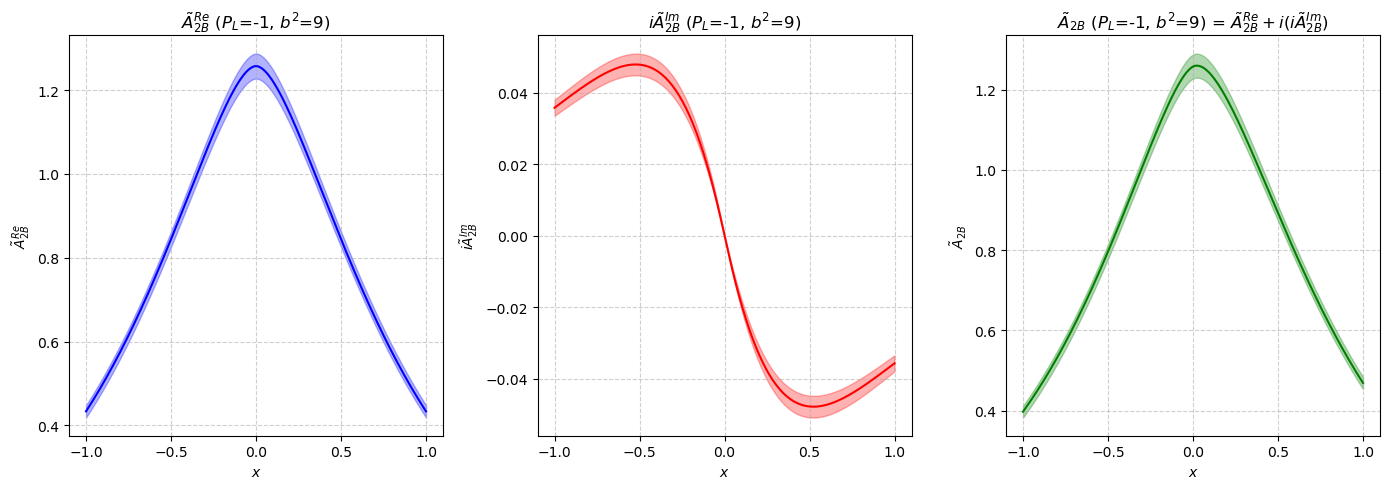

In [7]:
fig4, axes4 = plot_fourier_transforms(results_4, b2=9, PL=-1)

In [6]:
import h5py
import numpy as np
from scipy.integrate import simpson
import gvar as gv
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma
import inspect
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ---------------------------------------------------------
# 1. Jackknife Statistics Helper
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    # switch to scientific if very small/big
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        m_str = f"{mean:.2e}"           # e.g. "2.86e-08"
        mant, exp = m_str.split("e")
        ndec = len(mant.split(".")[1])  # digits in mantissa
        err_int = int(round(err / 10**int(exp) * 10**ndec))
        return f"{mant}({err_int})e{int(exp)}"
    else:
        ndec = 4                        # choose 4 decimal places
        m_str = f"{mean:.{ndec}f}"      # e.g. "0.4721"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int:0{ndec}d})"

# ---------------------------------------------------------
# 2. Data Loading & Filtering Helper
# ---------------------------------------------------------
def load_and_filter_data(filepath, bminForFit, etamin, etamax):
    """Loads HDF5 data and applies kinematic cuts."""
    with h5py.File(filepath, "r") as f:
        raw_data = f["Dataset1"][:]
        
    kin = raw_data[:, 0:3]
    samples = raw_data[:, 3:]
    
    eta = kin[:, 0]
    bL  = kin[:, 1]
    bT  = kin[:, 2]
    
    # Calculate b = sqrt(bL^2 + bT^2)
    b_mag = np.sqrt(bL**2 + bT**2)
    
    # Create a boolean mask for our cuts
    mask = (eta >= etamin) & (eta <= etamax) & (b_mag >= bminForFit)
    
    # Return only the rows that passed the cuts
    return kin[mask], samples[mask]


def load_and_filter_data_rm_0_bL(filepath, bminForFit, etamin, etamax):
    """Loads HDF5 data and applies kinematic cuts."""
    with h5py.File(filepath, "r") as f:
        raw_data = f["Dataset1"][:]
        
    kin = raw_data[:, 0:3]
    samples = raw_data[:, 3:]
    
    eta = kin[:, 0]
    bL  = kin[:, 1]
    bT  = kin[:, 2]
    
    # Calculate b = sqrt(bL^2 + bT^2)
    b_mag = np.sqrt(bL**2 + bT**2)
    
    # Create a boolean mask for our cuts
    mask = (eta >= etamin) & (eta <= etamax) & (b_mag >= bminForFit) & (bL != 0)
    
    # Return only the rows that passed the cuts
    return kin[mask], samples[mask]


def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, g, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.tanh(g*bL) * gv.exp(-f * eta) / denom


def fcn(x, p):
    # 1. Unpack the kinematic arrays from the dictionary x
    kin_re = x['Re']
    kin_im = x['Im']
    
    eta_re, bL_re, bT_re = kin_re[:, 0], kin_re[:, 1], kin_re[:, 2]
    eta_im, bL_im, bT_im = kin_im[:, 0], kin_im[:, 1], kin_im[:, 2]

    # Shared parameter
    f, k1, k2 = p['f'],  p['k1'], p['k2']
    
    # Real-specific parameters
    val_re = ReA2B(eta_re, bL_re, bT_re, p['a_re'], p['c_re'], p['d_re'], f, k1, k2, p['j_re'])
    
    # Imaginary-specific parameters
    val_im = ImA2B(eta_im, bL_im, bT_im, p['a_im'], p['c_im'], p['d_im'], p['g_im'], f, k1, k2, p['j_im'])
    
    return {'Re': val_re, 'Im': val_im}
    
# ---------------------------------------------------------
# 3. Main Simultaneous Fitting Function
# ---------------------------------------------------------
def FitSimultaneousA2B(PL, bminForFit, etamin, etamax):
    print(f"Simultaneous Fit (ReA2B & ImA2B) : PL={PL}, b_min>={bminForFit}, eta in [{etamin}, {etamax}] ---")
    print("\n--- Fit Functions ---")
    print(inspect.getsource(ReA2B))
    print(inspect.getsource(ImA2B))
    print("---------------------\n")
    
    # 1. Construct file paths (Update the base path if needed)
    base_path = "/pscratch/sd/h/hari_8/TMD_fit/h5data/"
    file_re = f"{base_path}/ReA2B_PL{PL}_jackknife_data.h5"
    file_im = f"{base_path}/ImA2B_PL{PL}_jackknife_data.h5"
    
    # 2. Load and Filter Data
    kin_re, jk_re = load_and_filter_data(file_re, bminForFit, etamin, etamax)
    kin_im, jk_im = load_and_filter_data_rm_0_bL(file_im, bminForFit, etamin, etamax)
    
    N_re = jk_re.shape[0]
    N_im = jk_im.shape[0]
    N_samples = jk_re.shape[1]
    
    print(f"Re A2B points: {N_re}, Im A2B points: {N_im}")

    # 3. Calculate the Full Jackknife Covariance Matrix
    combined_jk = np.vstack([jk_re, jk_im])
    mean_data = np.mean(combined_jk, axis=1)
    diff = combined_jk - mean_data[:, None]
    cov_matrix = ((N_samples - 1) / N_samples) * (diff @ diff.T)
    print(f"Covariance Matrix size: {cov_matrix.shape}")


    # ---------------------------------------------------------
    # Set up Priors
    # ---------------------------------------------------------
    current_prior = {
     'k1'  : gv.gvar(-5.83, 0.05),
     'k2'  : gv.gvar(-4.86, 0.05),
     #'k1_im'  : gv.gvar(-5.83, 0.05),
     #'k2_im'  : gv.gvar(-4.86, 0.05),
     'f'   : gv.gvar(0.50,  0.05),
     'a_re' : gv.gvar(4.01,  0.05),
     'c_re' : gv.gvar(0.60,  0.05),
     'd_re' : gv.gvar(0.094, 0.05),
     'j_re' : gv.gvar(2.06,  0.05),
     'a_im' : gv.gvar(0.100, 0.05),
     'c_im' : gv.gvar(0.60,  0.05),
     'd_im' : gv.gvar(0.094, 0.05),
     'g_im' : gv.gvar(0.2, 0.05),
     'j_im' : gv.gvar(2.06,  0.05),
    }


    x_dict = {'Re': kin_re, 'Im': kin_im}
    param_names = ['k1','k2','f','a_re','c_re','d_re','j_re','a_im','c_im','d_im','g_im','j_im']
    fitted_params = {key: [] for key in param_names}
    
    # We will also track chi-square per degree of freedom
    chi2_dof_list = []

    for i in tqdm(range(N_samples)):
        y_sample_i = combined_jk[:, i]
        y_gvar_i = gv.gvar(y_sample_i, cov_matrix)
        
        y_dict = {
            'Re': y_gvar_i[:N_re],
            'Im': y_gvar_i[N_re:]
        }
        
        fit = lsqfit.nonlinear_fit(data=(x_dict, y_dict), prior=current_prior, fcn=fcn, debug=False)
        
        for key in fitted_params:
            fitted_params[key].append(fit.pmean[key])
            
        #chi2_dof_list.append(fit.chi2 / (fit.dof - len(param_names)))
        dof = (N_re + N_im) - len(param_names)
        chi2_dof_list.append(fit.chi2 / dof)

    # 7. Apply Jackknife and Print Results
    print("\n--- Final Extracted Parameters ---")
    for key in fitted_params:
        mean_val, err_val = Jackknife(fitted_params[key])
        print(f"{key:>5} = {fmt_err(mean_val, err_val)}")
        
    mean_chi2, err_chi2 = Jackknife(chi2_dof_list)
    print(f"\n chi^2/dof : {fmt_err(mean_chi2, err_chi2)}\n")
    
    # Return the dictionary of jackknifed parameter arrays in case you want to plot them later
    return fitted_params


def plot_fourier_transforms(fitted_params, b2, PL, num_points=200):
    # 1. Setup x-axis
    x_vals = np.linspace(-1, 1, num_points)
    # The 1e-10 offset is less necessary for numerical FTs, but safe to keep
    x_vals[np.abs(x_vals) < 1e-10] = 1e-10 
    
    # 2. Extract parameters as NumPy arrays
    a_re = np.array(fitted_params['a_re'])
    c_re = np.array(fitted_params['c_re']) / (PL**2)
    d_re = 1.0 + np.array(fitted_params['d_re']) * b2  
    j_re = np.array(fitted_params['j_re'])

    a_im = np.array(fitted_params['a_im']) / PL
    c_im = np.array(fitted_params['c_im']) / (PL**2) # Using shared 'c'
    d_im = 1.0 + np.array(fitted_params['d_im']) * b2 # Using shared 'd'
    j_im = np.array(fitted_params['j_im']) # Using shared 'j'
    g_im = np.array(fitted_params['g_im'])

    # Note: Ensure you extract the shared c, d, j keys from fitted_params 
    # if you ran the shared-denominator fit as discussed! I assumed 'c', 'd', 'j' 
    # above, but if your dictionary still has 'c_re', change them accordingly.

    # Prepare lists to store the jackknife results for plotting
    re_mean, re_err = [], []
    im_mean, im_err = [], []
    full_mean, full_err = [], []

    print("Evaluating Fourier transforms numerically and applying Jackknife...")
    
    # --- SETUP VECTORIZED NUMERICAL INTEGRATION ---
    bL_grid = np.linspace(0, 100, 10000)
    
    # Reshape Real parameters to broadcast
    a_re_v = a_re[:, np.newaxis]
    c_re_v = c_re[:, np.newaxis]
    d_re_v = d_re[:, np.newaxis]
    j_re_v = j_re[:, np.newaxis]

    # Reshape Imaginary parameters to broadcast
    a_im_v = a_im[:, np.newaxis]
    c_im_v = c_im[:, np.newaxis]
    d_im_v = d_im[:, np.newaxis]
    j_im_v = j_im[:, np.newaxis]
    g_im_v = g_im[:, np.newaxis]
    
    # Precompute the coordinate-space functions for all samples and all grid points
    spatial_ReA2B = a_re_v / (c_re_v * bL_grid**2 + d_re_v)**j_re_v
    spatial_ImA2B = a_im_v * np.tanh(g_im_v * bL_grid) / (c_im_v * bL_grid**2 + d_im_v)**j_im_v
    
    # 3. Loop over each x value to evaluate the FT
    for x in x_vals:

        # --- Evaluate Real Part (Numerical Cosine Transform) ---
        # FT of an even function relies on cos(x * bL)
        integrand_R = spatial_ReA2B * np.cos(x * bL_grid)
        re_evals_at_x = np.sqrt(2/np.pi) * simpson(y=integrand_R, x=bL_grid, axis=1)
        
        m_re, e_re = Jackknife(re_evals_at_x)
        re_mean.append(m_re)
        re_err.append(e_re)

        # --- Evaluate Imaginary Part (Numerical Sine Transform) ---
        # FT of an odd function relies on sin(x * bL)
        integrand_I = spatial_ImA2B * np.sin(x * bL_grid)
        im_evals_at_x = np.sqrt(2/np.pi) * simpson(y=integrand_I, x=bL_grid, axis=1)
        
        m_im, e_im = Jackknife(im_evals_at_x)
        im_mean.append(m_im)
        im_err.append(e_im)

        # --- Evaluate Full T-Even Distribution ---
        m_full, e_full = Jackknife(re_evals_at_x - im_evals_at_x)
        full_mean.append(m_full)
        full_err.append(e_full)

    # Convert results to arrays for easier plotting
    re_mean, re_err = np.array(re_mean), np.array(re_err)
    im_mean, im_err = np.array(im_mean), np.array(im_err)
    full_mean, full_err = np.array(full_mean), np.array(full_err)

    # 4. Plotting
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

    # Real Plot
    ax1.plot(x_vals, re_mean, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, re_mean - re_err, re_mean + re_err, color='blue', alpha=0.3, label='Jackknife Error Band')
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($P_L$={PL}, $b^2$={b2})')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$\\tilde{{A}}_{{2B}}^{{Re}}$')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Imaginary Plot
    ax2.plot(x_vals, im_mean, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, im_mean - im_err, im_mean + im_err, color='red', alpha=0.3, label='Jackknife Error Band')
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($P_L$={PL}, $b^2$={b2})')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Full Plot
    ax3.plot(x_vals, full_mean, color='green', label='A2B Mean')
    ax3.fill_between(x_vals, full_mean - full_err, full_mean + full_err, color='green', alpha=0.3, label='Jackknife Error Band')
    ax3.set_title(f'$\\tilde{{A}}_{{2B}}$ ($P_L$={PL}, $b^2$={b2}) = $\\tilde{{A}}_{{2B}}^{{Re}}+i(i\\tilde{{A}}_{{2B}}^{{Im}})$')
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$\\tilde{{A}}_{{2B}}$')
    ax3.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    param_keys_str = "-".join(fitted_params.keys())
    file_name = f"/pscratch/sd/h/hari_8/TMD_fit/jupyter/SimulFitCovMatrix-A2B-FT-Numerical-{param_keys_str}.pdf"
    
    plt.savefig(file_name, format='pdf', bbox_inches='tight', dpi=1500)
    plt.show()

    return fig, (ax1, ax2, ax3)

Simultaneous Fit (ReA2B & ImA2B) : PL=-1, b_min>=3, eta in [6, 10] ---

--- Fit Functions ---
def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, g, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.tanh(g*bL) * gv.exp(-f * eta) / denom

---------------------

Re A2B points: 225, Im A2B points: 175
Covariance Matrix size: (400, 400)


  0%|          | 0/2903 [00:00<?, ?it/s]


--- Final Extracted Parameters ---
   k1 = -5.8415(0142)
   k2 = -4.8987(0083)
    f = 0.4731(0043)
 a_re = 3.8592(0105)
 c_re = 0.6608(0158)
 d_re = 0.1562(0062)
 j_re = 1.6679(0243)
 a_im = 0.2973(0149)
 c_im = 0.5455(0180)
 d_im = 0.0357(0022)
 g_im = 0.3005(0122)
 j_im = 2.0405(0084)

 chi^2/dof : 2.0645(1357)

Evaluating Fourier transforms and applying Jackknife...


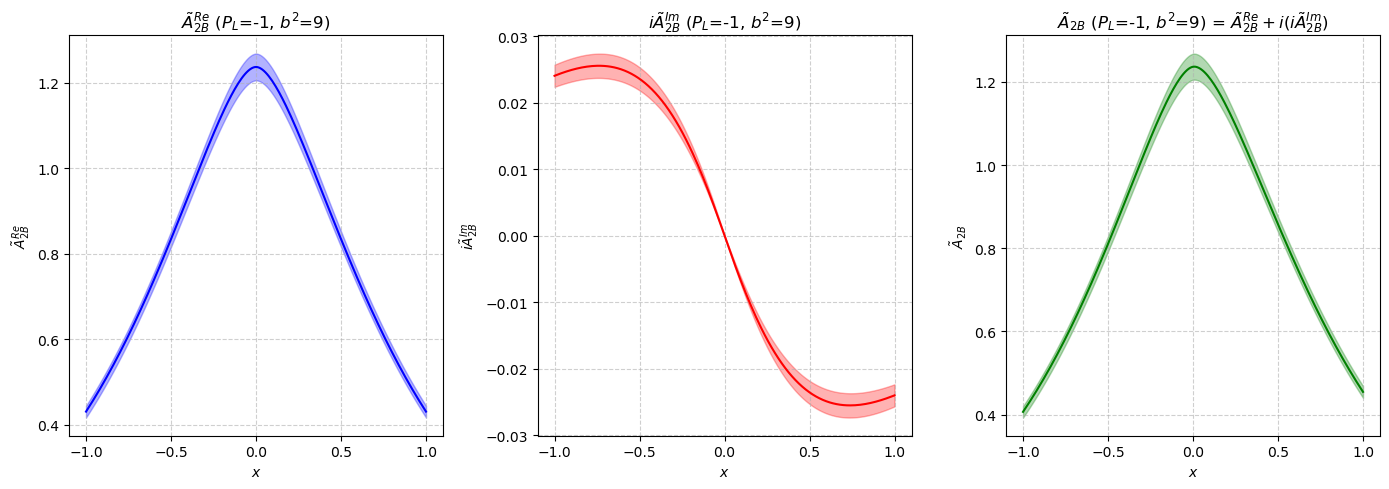

In [3]:
results_4 = FitSimultaneousA2B(PL=-1, bminForFit=3, etamin=6, etamax=10)
fig4, axes4 = plot_fourier_transforms(results_4, b2=9, PL=-1)


Evaluating Fourier transforms numerically and applying Jackknife...


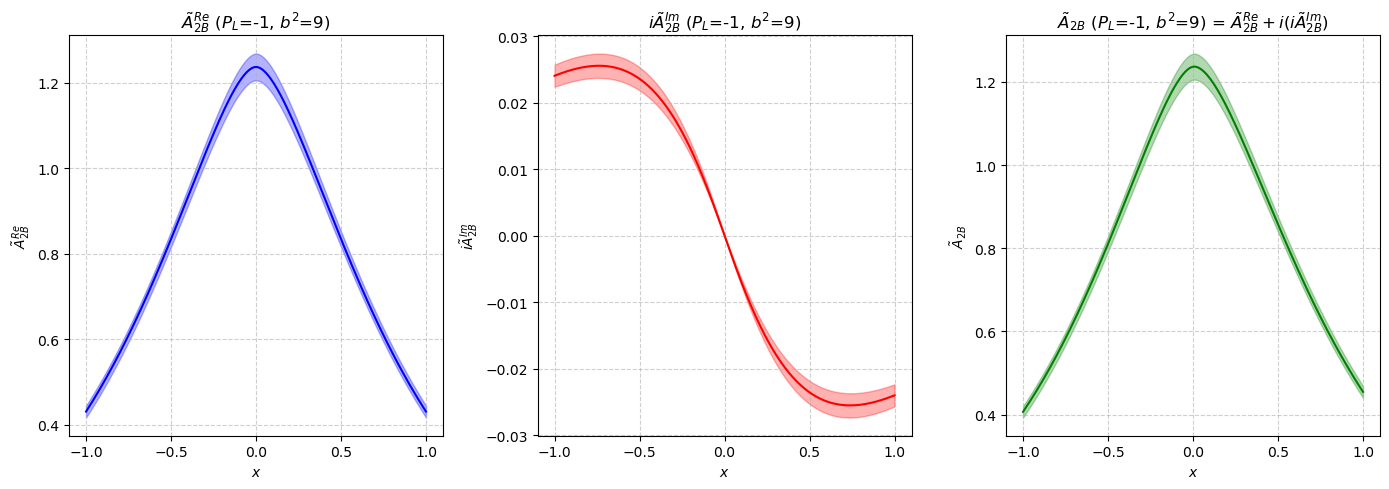

In [7]:
fig4, axes4 = plot_fourier_transforms(results_4, b2=9, PL=-1)

In [2]:
import h5py
import numpy as np
from scipy.integrate import simpson
import gvar as gv
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma
import inspect
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ---------------------------------------------------------
# 1. Jackknife Statistics Helper
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    # switch to scientific if very small/big
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        m_str = f"{mean:.2e}"           # e.g. "2.86e-08"
        mant, exp = m_str.split("e")
        ndec = len(mant.split(".")[1])  # digits in mantissa
        err_int = int(round(err / 10**int(exp) * 10**ndec))
        return f"{mant}({err_int})e{int(exp)}"
    else:
        ndec = 4                        # choose 4 decimal places
        m_str = f"{mean:.{ndec}f}"      # e.g. "0.4721"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int:0{ndec}d})"

# ---------------------------------------------------------
# 2. Data Loading & Filtering Helper
# ---------------------------------------------------------
def load_and_filter_data(filepath, bminForFit, etamin, etamax):
    """Loads HDF5 data and applies kinematic cuts."""
    with h5py.File(filepath, "r") as f:
        raw_data = f["Dataset1"][:]
        
    kin = raw_data[:, 0:3]
    samples = raw_data[:, 3:]
    
    eta = kin[:, 0]
    bL  = kin[:, 1]
    bT  = kin[:, 2]
    
    # Calculate b = sqrt(bL^2 + bT^2)
    b_mag = np.sqrt(bL**2 + bT**2)
    
    # Create a boolean mask for our cuts
    mask = (eta >= etamin) & (eta <= etamax) & (b_mag >= bminForFit)
    
    # Return only the rows that passed the cuts
    return kin[mask], samples[mask]


def load_and_filter_data_rm_0_bL(filepath, bminForFit, etamin, etamax):
    """Loads HDF5 data and applies kinematic cuts."""
    with h5py.File(filepath, "r") as f:
        raw_data = f["Dataset1"][:]
        
    kin = raw_data[:, 0:3]
    samples = raw_data[:, 3:]
    
    eta = kin[:, 0]
    bL  = kin[:, 1]
    bT  = kin[:, 2]
    
    # Calculate b = sqrt(bL^2 + bT^2)
    b_mag = np.sqrt(bL**2 + bT**2)
    
    # Create a boolean mask for our cuts
    mask = (eta >= etamin) & (eta <= etamax) & (b_mag >= bminForFit) & (bL != 0)
    
    # Return only the rows that passed the cuts
    return kin[mask], samples[mask]


def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, g, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.tanh(g*bL) * gv.exp(-f * eta) / denom


def fcn(x, p):
    # 1. Unpack the kinematic arrays from the dictionary x
    kin_re = x['Re']
    kin_im = x['Im']
    
    eta_re, bL_re, bT_re = kin_re[:, 0], kin_re[:, 1], kin_re[:, 2]
    eta_im, bL_im, bT_im = kin_im[:, 0], kin_im[:, 1], kin_im[:, 2]

    # Shared parameter
    f, k1, k2, j = p['f'],  p['k1'], p['k2'], p['j']
    
    # Real-specific parameters
    val_re = ReA2B(eta_re, bL_re, bT_re, p['a_re'], p['c_re'], p['d_re'], f, k1, k2, j)
    
    # Imaginary-specific parameters
    val_im = ImA2B(eta_im, bL_im, bT_im, p['a_im'], p['c_im'], p['d_im'], p['g_im'], f, k1, k2, j)
    
    return {'Re': val_re, 'Im': val_im}
    
# ---------------------------------------------------------
# 3. Main Simultaneous Fitting Function
# ---------------------------------------------------------
def FitSimultaneousA2B(PL, bminForFit, etamin, etamax):
    print(f"Simultaneous Fit (ReA2B & ImA2B) : PL={PL}, b_min>={bminForFit}, eta in [{etamin}, {etamax}] ---")
    print("\n--- Fit Functions ---")
    print(inspect.getsource(ReA2B))
    print(inspect.getsource(ImA2B))
    print("---------------------\n")
    
    # 1. Construct file paths (Update the base path if needed)
    base_path = "/pscratch/sd/h/hari_8/TMD_fit/h5data/"
    file_re = f"{base_path}/ReA2B_PL{PL}_jackknife_data.h5"
    file_im = f"{base_path}/ImA2B_PL{PL}_jackknife_data.h5"
    
    # 2. Load and Filter Data
    kin_re, jk_re = load_and_filter_data(file_re, bminForFit, etamin, etamax)
    kin_im, jk_im = load_and_filter_data_rm_0_bL(file_im, bminForFit, etamin, etamax)
    
    N_re = jk_re.shape[0]
    N_im = jk_im.shape[0]
    N_samples = jk_re.shape[1]
    
    print(f"Re A2B points: {N_re}, Im A2B points: {N_im}")

    # 3. Calculate the Full Jackknife Covariance Matrix
    combined_jk = np.vstack([jk_re, jk_im])
    mean_data = np.mean(combined_jk, axis=1)
    diff = combined_jk - mean_data[:, None]
    cov_matrix = ((N_samples - 1) / N_samples) * (diff @ diff.T)
    print(f"Covariance Matrix size: {cov_matrix.shape}")


    # ---------------------------------------------------------
    # Set up Priors
    # ---------------------------------------------------------
    current_prior = {
     'k1'  : gv.gvar(-5.83, 0.05),
     'k2'  : gv.gvar(-4.86, 0.05),
     #'k1_im'  : gv.gvar(-5.83, 0.05),
     #'k2_im'  : gv.gvar(-4.86, 0.05),
     'f'   : gv.gvar(0.50,  0.05),
     'a_re' : gv.gvar(4.01,  0.05),
     'c_re' : gv.gvar(0.60,  0.05),
     'd_re' : gv.gvar(0.094, 0.05),
     'j' : gv.gvar(2.06,  0.05),
     'a_im' : gv.gvar(0.100, 0.05),
     'c_im' : gv.gvar(0.60,  0.05),
     'd_im' : gv.gvar(0.094, 0.05),
     'g_im' : gv.gvar(0.2, 0.05),
     #'j_im' : gv.gvar(2.06,  0.05),
    }


    x_dict = {'Re': kin_re, 'Im': kin_im}
    param_names = ['k1','k2','f','a_re','c_re','d_re','j','a_im','c_im','d_im','g_im']
    fitted_params = {key: [] for key in param_names}
    
    # We will also track chi-square per degree of freedom
    chi2_dof_list = []

    for i in tqdm(range(N_samples)):
        y_sample_i = combined_jk[:, i]
        y_gvar_i = gv.gvar(y_sample_i, cov_matrix)
        
        y_dict = {
            'Re': y_gvar_i[:N_re],
            'Im': y_gvar_i[N_re:]
        }
        
        fit = lsqfit.nonlinear_fit(data=(x_dict, y_dict), prior=current_prior, fcn=fcn, debug=False)
        
        for key in fitted_params:
            fitted_params[key].append(fit.pmean[key])
            
        #chi2_dof_list.append(fit.chi2 / (fit.dof - len(param_names)))
        dof = (N_re + N_im) - len(param_names)
        chi2_dof_list.append(fit.chi2 / dof)

    # 7. Apply Jackknife and Print Results
    print("\n--- Final Extracted Parameters ---")
    for key in fitted_params:
        mean_val, err_val = Jackknife(fitted_params[key])
        print(f"{key:>5} = {fmt_err(mean_val, err_val)}")
        
    mean_chi2, err_chi2 = Jackknife(chi2_dof_list)
    print(f"\n chi^2/dof : {fmt_err(mean_chi2, err_chi2)}\n")
    
    # Return the dictionary of jackknifed parameter arrays in case you want to plot them later
    return fitted_params


def plot_fourier_transforms(fitted_params, b2, PL, num_points=200):
    # 1. Setup x-axis
    x_vals = np.linspace(-1, 1, num_points)
    # The 1e-10 offset is less necessary for numerical FTs, but safe to keep
    x_vals[np.abs(x_vals) < 1e-10] = 1e-10 
    
    # 2. Extract parameters as NumPy arrays
    a_re = np.array(fitted_params['a_re'])
    c_re = np.array(fitted_params['c_re']) / (PL**2)
    d_re = 1.0 + np.array(fitted_params['d_re']) * b2  
    j_re = np.array(fitted_params['j'])

    a_im = np.array(fitted_params['a_im']) / PL
    c_im = np.array(fitted_params['c_im']) / (PL**2) # Using shared 'c'
    d_im = 1.0 + np.array(fitted_params['d_im']) * b2 # Using shared 'd'
    j_im = np.array(fitted_params['j']) # Using shared 'j'
    g_im = np.array(fitted_params['g_im'])

    # Note: Ensure you extract the shared c, d, j keys from fitted_params 
    # if you ran the shared-denominator fit as discussed! I assumed 'c', 'd', 'j' 
    # above, but if your dictionary still has 'c_re', change them accordingly.

    # Prepare lists to store the jackknife results for plotting
    re_mean, re_err = [], []
    im_mean, im_err = [], []
    full_mean, full_err = [], []

    print("Evaluating Fourier transforms numerically and applying Jackknife...")
    
    # --- SETUP VECTORIZED NUMERICAL INTEGRATION ---
    bL_grid = np.linspace(0, 100, 10000)
    
    # Reshape Real parameters to broadcast
    a_re_v = a_re[:, np.newaxis]
    c_re_v = c_re[:, np.newaxis]
    d_re_v = d_re[:, np.newaxis]
    j_re_v = j_re[:, np.newaxis]

    # Reshape Imaginary parameters to broadcast
    a_im_v = a_im[:, np.newaxis]
    c_im_v = c_im[:, np.newaxis]
    d_im_v = d_im[:, np.newaxis]
    j_im_v = j_im[:, np.newaxis]
    g_im_v = g_im[:, np.newaxis]
    
    # Precompute the coordinate-space functions for all samples and all grid points
    spatial_ReA2B = a_re_v / (c_re_v * bL_grid**2 + d_re_v)**j_re_v
    spatial_ImA2B = a_im_v * np.tanh(g_im_v * bL_grid) / (c_im_v * bL_grid**2 + d_im_v)**j_im_v
    
    # 3. Loop over each x value to evaluate the FT
    for x in x_vals:

        # --- Evaluate Real Part (Numerical Cosine Transform) ---
        # FT of an even function relies on cos(x * bL)
        integrand_R = spatial_ReA2B * np.cos(x * bL_grid)
        re_evals_at_x = np.sqrt(2/np.pi) * simpson(y=integrand_R, x=bL_grid, axis=1)
        
        m_re, e_re = Jackknife(re_evals_at_x)
        re_mean.append(m_re)
        re_err.append(e_re)

        # --- Evaluate Imaginary Part (Numerical Sine Transform) ---
        # FT of an odd function relies on sin(x * bL)
        integrand_I = spatial_ImA2B * np.sin(x * bL_grid)
        im_evals_at_x = np.sqrt(2/np.pi) * simpson(y=integrand_I, x=bL_grid, axis=1)
        
        m_im, e_im = Jackknife(im_evals_at_x)
        im_mean.append(m_im)
        im_err.append(e_im)

        # --- Evaluate Full T-Even Distribution ---
        m_full, e_full = Jackknife(re_evals_at_x - im_evals_at_x)
        full_mean.append(m_full)
        full_err.append(e_full)

    # Convert results to arrays for easier plotting
    re_mean, re_err = np.array(re_mean), np.array(re_err)
    im_mean, im_err = np.array(im_mean), np.array(im_err)
    full_mean, full_err = np.array(full_mean), np.array(full_err)

    # 4. Plotting
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

    # Real Plot
    ax1.plot(x_vals, re_mean, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, re_mean - re_err, re_mean + re_err, color='blue', alpha=0.3, label='Jackknife Error Band')
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($P_L$={PL}, $b^2$={b2})')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$\\tilde{{A}}_{{2B}}^{{Re}}$')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Imaginary Plot
    ax2.plot(x_vals, im_mean, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, im_mean - im_err, im_mean + im_err, color='red', alpha=0.3, label='Jackknife Error Band')
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($P_L$={PL}, $b^2$={b2})')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Full Plot
    ax3.plot(x_vals, full_mean, color='green', label='A2B Mean')
    ax3.fill_between(x_vals, full_mean - full_err, full_mean + full_err, color='green', alpha=0.3, label='Jackknife Error Band')
    ax3.set_title(f'$\\tilde{{A}}_{{2B}}$ ($P_L$={PL}, $b^2$={b2}) = $\\tilde{{A}}_{{2B}}^{{Re}}+i(i\\tilde{{A}}_{{2B}}^{{Im}})$')
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$\\tilde{{A}}_{{2B}}$')
    ax3.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    param_keys_str = "-".join(fitted_params.keys())
    file_name = f"/pscratch/sd/h/hari_8/TMD_fit/jupyter/SimulFitCovMatrix-A2B-FT-Numerical-{param_keys_str}.pdf"
    
    plt.savefig(file_name, format='pdf', bbox_inches='tight', dpi=1500)
    plt.show()

    return fig, (ax1, ax2, ax3)

Simultaneous Fit (ReA2B & ImA2B) : PL=-1, b_min>=3, eta in [6, 10] ---

--- Fit Functions ---
def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, g, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.tanh(g*bL) * gv.exp(-f * eta) / denom

---------------------

Re A2B points: 225, Im A2B points: 175
Covariance Matrix size: (400, 400)


  0%|          | 0/2903 [00:00<?, ?it/s]


--- Final Extracted Parameters ---
   k1 = -5.8257(0130)
   k2 = -4.8979(0084)
    f = 0.4724(0043)
 a_re = 3.8652(0102)
 c_re = 0.6429(0168)
 d_re = 0.1577(0064)
    j = 1.6658(0240)
 a_im = 0.3025(0148)
 c_im = 0.5909(0159)
 d_im = 0.0459(0031)
 g_im = 0.3010(0121)

 chi^2/dof : 2.0522(1353)

Evaluating Fourier transforms numerically and applying Jackknife...


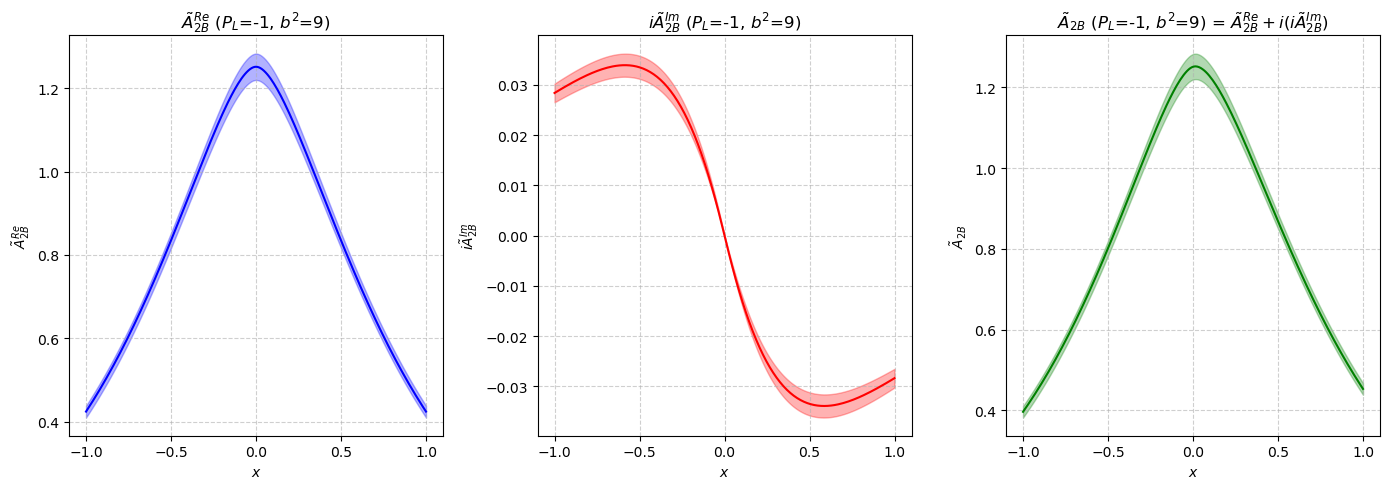

In [3]:
results_4 = FitSimultaneousA2B(PL=-1, bminForFit=3, etamin=6, etamax=10)
fig4, axes4 = plot_fourier_transforms(results_4, b2=9, PL=-1)


In [ ]:
results_4 = FitSimultaneousA2B(PL=-2, bminForFit=3, etamin=6, etamax=10)
fig4, axes4 = plot_fourier_transforms(results_4, b2=9, PL=-2)


Simultaneous Fit (ReA2B & ImA2B) : PL=-2, b_min>=3, eta in [6, 10] ---

--- Fit Functions ---
def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, g, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.tanh(g*bL) * gv.exp(-f * eta) / denom

---------------------

Re A2B points: 225, Im A2B points: 175
Covariance Matrix size: (400, 400)


  0%|          | 0/2903 [00:00<?, ?it/s]


--- Final Extracted Parameters ---
   k1 = -5.7944(0114)
   k2 = -4.8802(0098)
    f = 0.5059(0071)
 a_re = 3.9751(0064)
 c_re = 0.6051(0155)
 d_re = 0.1240(0055)
    j = 2.0194(0219)
 a_im = 0.4343(0170)
 c_im = 0.5826(0178)
 d_im = 0.0334(0026)
 g_im = 0.3818(0125)

 chi^2/dof : 1.2684(1059)

Evaluating Fourier transforms numerically and applying Jackknife...


In [2]:
import h5py
import numpy as np
from scipy.integrate import simpson
import gvar as gv
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma
import inspect
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ---------------------------------------------------------
# 1. Jackknife Statistics Helper
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    # switch to scientific if very small/big
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        m_str = f"{mean:.2e}"           # e.g. "2.86e-08"
        mant, exp = m_str.split("e")
        ndec = len(mant.split(".")[1])  # digits in mantissa
        err_int = int(round(err / 10**int(exp) * 10**ndec))
        return f"{mant}({err_int})e{int(exp)}"
    else:
        ndec = 4                        # choose 4 decimal places
        m_str = f"{mean:.{ndec}f}"      # e.g. "0.4721"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int:0{ndec}d})"

# ---------------------------------------------------------
# 2. Data Loading & Filtering Helper
# ---------------------------------------------------------
def load_and_filter_data(filepath, bminForFit, etamin, etamax):
    """Loads HDF5 data and applies kinematic cuts."""
    with h5py.File(filepath, "r") as f:
        raw_data = f["Dataset1"][:]
        
    kin = raw_data[:, 0:3]
    samples = raw_data[:, 3:]
    
    eta = kin[:, 0]
    bL  = kin[:, 1]
    bT  = kin[:, 2]
    
    # Calculate b = sqrt(bL^2 + bT^2)
    b_mag = np.sqrt(bL**2 + bT**2)
    
    # Create a boolean mask for our cuts
    mask = (eta >= etamin) & (eta <= etamax) & (b_mag >= bminForFit)
    
    # Return only the rows that passed the cuts
    return kin[mask], samples[mask]


def load_and_filter_data_rm_0_bL(filepath, bminForFit, etamin, etamax):
    """Loads HDF5 data and applies kinematic cuts."""
    with h5py.File(filepath, "r") as f:
        raw_data = f["Dataset1"][:]
        
    kin = raw_data[:, 0:3]
    samples = raw_data[:, 3:]
    
    eta = kin[:, 0]
    bL  = kin[:, 1]
    bT  = kin[:, 2]
    
    # Calculate b = sqrt(bL^2 + bT^2)
    b_mag = np.sqrt(bL**2 + bT**2)
    
    # Create a boolean mask for our cuts
    mask = (eta >= etamin) & (eta <= etamax) & (b_mag >= bminForFit) & (bL != 0)
    
    # Return only the rows that passed the cuts
    return kin[mask], samples[mask]


def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, g, f, j):
    denom = (1 + (d + c) * bL**2 + d * bT**2)**j
    return a * gv.tanh(g*bL) * gv.exp(-f * eta) / denom


def fcn(x, p):
    # 1. Unpack the kinematic arrays from the dictionary x
    kin_re = x['Re']
    kin_im = x['Im']
    
    eta_re, bL_re, bT_re = kin_re[:, 0], kin_re[:, 1], kin_re[:, 2]
    eta_im, bL_im, bT_im = kin_im[:, 0], kin_im[:, 1], kin_im[:, 2]

    # Shared parameter
    f, k1, k2, j = p['f'],  p['k1'], p['k2'], p['j']
    
    # Real-specific parameters
    val_re = ReA2B(eta_re, bL_re, bT_re, p['a_re'], p['c_re'], p['d_re'], f, k1, k2, j)
    
    # Imaginary-specific parameters
    val_im = ImA2B(eta_im, bL_im, bT_im, p['a_im'], p['c_im'], p['d_im'], p['g_im'], f, j)
    
    return {'Re': val_re, 'Im': val_im}
    
# ---------------------------------------------------------
# 3. Main Simultaneous Fitting Function
# ---------------------------------------------------------
def FitSimultaneousA2B(PL, bminForFit, etamin, etamax):
    print(f"Simultaneous Fit (ReA2B & ImA2B) : PL={PL}, b_min>={bminForFit}, eta in [{etamin}, {etamax}] ---")
    print("\n--- Fit Functions ---")
    print(inspect.getsource(ReA2B))
    print(inspect.getsource(ImA2B))
    print("---------------------\n")
    
    # 1. Construct file paths (Update the base path if needed)
    base_path = "/pscratch/sd/h/hari_8/TMD_fit/h5data/"
    file_re = f"{base_path}/ReA2B_PL{PL}_jackknife_data.h5"
    file_im = f"{base_path}/ImA2B_PL{PL}_jackknife_data.h5"
    
    # 2. Load and Filter Data
    kin_re, jk_re = load_and_filter_data(file_re, bminForFit, etamin, etamax)
    kin_im, jk_im = load_and_filter_data_rm_0_bL(file_im, bminForFit, etamin, etamax)
    
    N_re = jk_re.shape[0]
    N_im = jk_im.shape[0]
    N_samples = jk_re.shape[1]
    
    print(f"Re A2B points: {N_re}, Im A2B points: {N_im}")

    # 3. Calculate the Full Jackknife Covariance Matrix
    combined_jk = np.vstack([jk_re, jk_im])
    mean_data = np.mean(combined_jk, axis=1)
    diff = combined_jk - mean_data[:, None]
    cov_matrix = ((N_samples - 1) / N_samples) * (diff @ diff.T)
    print(f"Covariance Matrix size: {cov_matrix.shape}")


    # ---------------------------------------------------------
    # Set up Priors
    # ---------------------------------------------------------
    current_prior = {
     'k1'  : gv.gvar(-5.83, 0.05),
     'k2'  : gv.gvar(-4.86, 0.05),
     #'k1_im'  : gv.gvar(-5.83, 0.05),
     #'k2_im'  : gv.gvar(-4.86, 0.05),
     'f'   : gv.gvar(0.50,  0.05),
     'a_re' : gv.gvar(4.01,  0.05),
     'c_re' : gv.gvar(0.60,  0.05),
     'd_re' : gv.gvar(0.094, 0.05),
     'j' : gv.gvar(2.06,  0.05),
     'a_im' : gv.gvar(0.100, 0.05),
     'c_im' : gv.gvar(0.60,  0.005),
     'd_im' : gv.gvar(0.094, 0.05),
     'g_im' : gv.gvar(0.2, 0.05),
     #'j_im' : gv.gvar(2.06,  0.05),
    }


    x_dict = {'Re': kin_re, 'Im': kin_im}
    param_names = ['k1','k2','f','a_re','c_re','d_re','j','a_im','c_im','d_im','g_im']
    fitted_params = {key: [] for key in param_names}
    
    # We will also track chi-square per degree of freedom
    chi2_dof_list = []

    for i in tqdm(range(N_samples)):
        y_sample_i = combined_jk[:, i]
        y_gvar_i = gv.gvar(y_sample_i, cov_matrix)
        
        y_dict = {
            'Re': y_gvar_i[:N_re],
            'Im': y_gvar_i[N_re:]
        }
        
        fit = lsqfit.nonlinear_fit(data=(x_dict, y_dict), prior=current_prior, fcn=fcn, debug=False)
        
        for key in fitted_params:
            fitted_params[key].append(fit.pmean[key])
            
        #chi2_dof_list.append(fit.chi2 / (fit.dof - len(param_names)))
        dof = (N_re + N_im) - len(param_names)
        chi2_dof_list.append(fit.chi2 / dof)

    # 7. Apply Jackknife and Print Results
    print("\n--- Final Extracted Parameters ---")
    for key in fitted_params:
        mean_val, err_val = Jackknife(fitted_params[key])
        print(f"{key:>5} = {fmt_err(mean_val, err_val)}")
        
    mean_chi2, err_chi2 = Jackknife(chi2_dof_list)
    print(f"\n chi^2/dof : {fmt_err(mean_chi2, err_chi2)}\n")
    
    # Return the dictionary of jackknifed parameter arrays in case you want to plot them later
    return fitted_params


def plot_fourier_transforms(fitted_params, b2, PL, num_points=200):
    # 1. Setup x-axis
    x_vals = np.linspace(-1, 1, num_points)
    # The 1e-10 offset is less necessary for numerical FTs, but safe to keep
    x_vals[np.abs(x_vals) < 1e-10] = 1e-10 
    
    # 2. Extract parameters as NumPy arrays
    a_re = np.array(fitted_params['a_re'])
    c_re = np.array(fitted_params['c_re']) / (PL**2)
    d_re = 1.0 + np.array(fitted_params['d_re']) * b2  
    j_re = np.array(fitted_params['j'])

    a_im = np.array(fitted_params['a_im']) / PL
    c_im = np.array(fitted_params['c_im']) / (PL**2) # Using shared 'c'
    d_im = 1.0 + np.array(fitted_params['d_im']) * b2 # Using shared 'd'
    j_im = np.array(fitted_params['j']) # Using shared 'j'
    g_im = np.array(fitted_params['g_im'])

    # Note: Ensure you extract the shared c, d, j keys from fitted_params 
    # if you ran the shared-denominator fit as discussed! I assumed 'c', 'd', 'j' 
    # above, but if your dictionary still has 'c_re', change them accordingly.

    # Prepare lists to store the jackknife results for plotting
    re_mean, re_err = [], []
    im_mean, im_err = [], []
    full_mean, full_err = [], []

    print("Evaluating Fourier transforms numerically and applying Jackknife...")
    
    # --- SETUP VECTORIZED NUMERICAL INTEGRATION ---
    bL_grid = np.linspace(0, 100, 10000)
    
    # Reshape Real parameters to broadcast
    a_re_v = a_re[:, np.newaxis]
    c_re_v = c_re[:, np.newaxis]
    d_re_v = d_re[:, np.newaxis]
    j_re_v = j_re[:, np.newaxis]

    # Reshape Imaginary parameters to broadcast
    a_im_v = a_im[:, np.newaxis]
    c_im_v = c_im[:, np.newaxis]
    d_im_v = d_im[:, np.newaxis]
    j_im_v = j_im[:, np.newaxis]
    g_im_v = g_im[:, np.newaxis]
    
    # Precompute the coordinate-space functions for all samples and all grid points
    spatial_ReA2B = a_re_v / (c_re_v * bL_grid**2 + d_re_v)**j_re_v
    spatial_ImA2B = a_im_v * np.tanh(g_im_v * bL_grid) / (c_im_v * bL_grid**2 + d_im_v)**j_im_v
    
    # 3. Loop over each x value to evaluate the FT
    for x in x_vals:

        # --- Evaluate Real Part (Numerical Cosine Transform) ---
        # FT of an even function relies on cos(x * bL)
        integrand_R = spatial_ReA2B * np.cos(x * bL_grid)
        re_evals_at_x = np.sqrt(2/np.pi) * simpson(y=integrand_R, x=bL_grid, axis=1)
        
        m_re, e_re = Jackknife(re_evals_at_x)
        re_mean.append(m_re)
        re_err.append(e_re)

        # --- Evaluate Imaginary Part (Numerical Sine Transform) ---
        # FT of an odd function relies on sin(x * bL)
        integrand_I = spatial_ImA2B * np.sin(x * bL_grid)
        im_evals_at_x = np.sqrt(2/np.pi) * simpson(y=integrand_I, x=bL_grid, axis=1)
        
        m_im, e_im = Jackknife(im_evals_at_x)
        im_mean.append(m_im)
        im_err.append(e_im)

        # --- Evaluate Full T-Even Distribution ---
        m_full, e_full = Jackknife(re_evals_at_x - im_evals_at_x)
        full_mean.append(m_full)
        full_err.append(e_full)

    # Convert results to arrays for easier plotting
    re_mean, re_err = np.array(re_mean), np.array(re_err)
    im_mean, im_err = np.array(im_mean), np.array(im_err)
    full_mean, full_err = np.array(full_mean), np.array(full_err)

    # 4. Plotting
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

    # Real Plot
    ax1.plot(x_vals, re_mean, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, re_mean - re_err, re_mean + re_err, color='blue', alpha=0.3, label='Jackknife Error Band')
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($P_L$={PL}, $b^2$={b2})')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$\\tilde{{A}}_{{2B}}^{{Re}}$')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Imaginary Plot
    ax2.plot(x_vals, im_mean, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, im_mean - im_err, im_mean + im_err, color='red', alpha=0.3, label='Jackknife Error Band')
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($P_L$={PL}, $b^2$={b2})')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Full Plot
    ax3.plot(x_vals, full_mean, color='green', label='A2B Mean')
    ax3.fill_between(x_vals, full_mean - full_err, full_mean + full_err, color='green', alpha=0.3, label='Jackknife Error Band')
    ax3.set_title(f'$\\tilde{{A}}_{{2B}}$ ($P_L$={PL}, $b^2$={b2}) = $\\tilde{{A}}_{{2B}}^{{Re}}+i(i\\tilde{{A}}_{{2B}}^{{Im}})$')
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$\\tilde{{A}}_{{2B}}$')
    ax3.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    param_keys_str = "-".join(fitted_params.keys())
    file_name = f"/pscratch/sd/h/hari_8/TMD_fit/jupyter/SimulFitCovMatrix-A2B-FT-Numerical-{param_keys_str}.pdf"
    
    plt.savefig(file_name, format='pdf', bbox_inches='tight', dpi=1500)
    plt.show()

    return fig, (ax1, ax2, ax3)

Simultaneous Fit (ReA2B & ImA2B) : PL=-1, b_min>=3, eta in [6, 10] ---

--- Fit Functions ---
def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, g, f, j):
    denom = (1 + (d + c) * bL**2 + d * bT**2)**j
    return a * gv.tanh(g*bL) * gv.exp(-f * eta) / denom

---------------------

Re A2B points: 225, Im A2B points: 175
Covariance Matrix size: (400, 400)


  0%|          | 0/2903 [00:00<?, ?it/s]


--- Final Extracted Parameters ---
   k1 = -5.7979(0110)
   k2 = -4.8879(0086)
    f = 0.4748(0047)
 a_re = 3.8738(0101)
 c_re = 0.6480(0135)
 d_re = 0.1612(0075)
    j = 1.6415(0273)
 a_im = 0.2346(0203)
 c_im = 0.5992(0002)
 d_im = 0.0543(0161)
 g_im = 0.2548(0096)

 chi^2/dof : 3.4262(1806)

Evaluating Fourier transforms numerically and applying Jackknife...


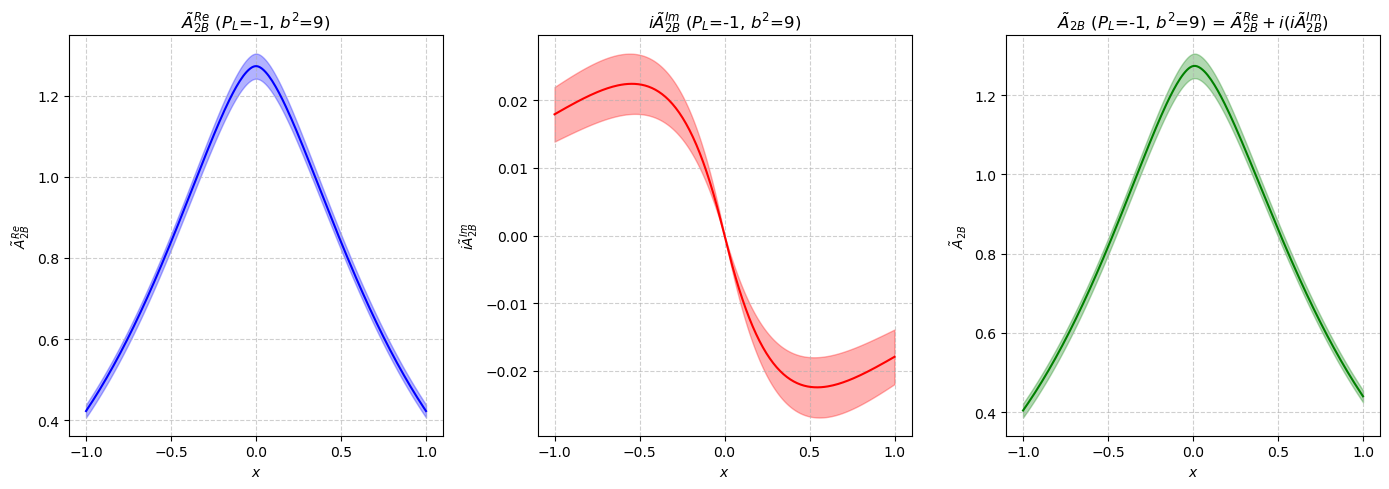

In [3]:
results_4 = FitSimultaneousA2B(PL=-1, bminForFit=3, etamin=6, etamax=10)
fig4, axes4 = plot_fourier_transforms(results_4, b2=9, PL=-1)

In [1]:
import h5py
import numpy as np
from scipy.integrate import simpson
import gvar as gv
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma
import inspect
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ---------------------------------------------------------
# 1. Jackknife Statistics Helper
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    # switch to scientific if very small/big
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        m_str = f"{mean:.2e}"           # e.g. "2.86e-08"
        mant, exp = m_str.split("e")
        ndec = len(mant.split(".")[1])  # digits in mantissa
        err_int = int(round(err / 10**int(exp) * 10**ndec))
        return f"{mant}({err_int})e{int(exp)}"
    else:
        ndec = 4                        # choose 4 decimal places
        m_str = f"{mean:.{ndec}f}"      # e.g. "0.4721"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int:0{ndec}d})"

# ---------------------------------------------------------
# 2. Data Loading & Filtering Helper
# ---------------------------------------------------------
def load_and_filter_data(filepath, bminForFit, etamin, etamax):
    """Loads HDF5 data and applies kinematic cuts."""
    with h5py.File(filepath, "r") as f:
        raw_data = f["Dataset1"][:]
        
    kin = raw_data[:, 0:3]
    samples = raw_data[:, 3:]
    
    eta = kin[:, 0]
    bL  = kin[:, 1]
    bT  = kin[:, 2]
    
    # Calculate b = sqrt(bL^2 + bT^2)
    b_mag = np.sqrt(bL**2 + bT**2)
    
    # Create a boolean mask for our cuts
    mask = (eta >= etamin) & (eta <= etamax) & (b_mag >= bminForFit)
    
    # Return only the rows that passed the cuts
    return kin[mask], samples[mask]


def load_and_filter_data_rm_0_bL(filepath, bminForFit, etamin, etamax):
    """Loads HDF5 data and applies kinematic cuts."""
    with h5py.File(filepath, "r") as f:
        raw_data = f["Dataset1"][:]
        
    kin = raw_data[:, 0:3]
    samples = raw_data[:, 3:]
    
    eta = kin[:, 0]
    bL  = kin[:, 1]
    bT  = kin[:, 2]
    
    # Calculate b = sqrt(bL^2 + bT^2)
    b_mag = np.sqrt(bL**2 + bT**2)
    
    # Create a boolean mask for our cuts
    mask = (eta >= etamin) & (eta <= etamax) & (b_mag >= bminForFit) & (bL != 0)
    
    # Return only the rows that passed the cuts
    return kin[mask], samples[mask]


def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, g, f, j):
    denom = (1 + (d + c) * bL**2 + d * bT**2)**j
    return a * gv.tanh(g*bL) * gv.exp(-f * eta) / denom


def fcn(x, p):
    # 1. Unpack the kinematic arrays from the dictionary x
    kin_re = x['Re']
    kin_im = x['Im']
    
    eta_re, bL_re, bT_re = kin_re[:, 0], kin_re[:, 1], kin_re[:, 2]
    eta_im, bL_im, bT_im = kin_im[:, 0], kin_im[:, 1], kin_im[:, 2]

    # Shared parameter
    f = p['f']
    
    # Real-specific parameters
    val_re = ReA2B(eta_re, bL_re, bT_re, p['a_re'], p['c_re'], p['d_re'], f,  p['k1_re'], p['k2_re'],  p['j_re'])
    
    # Imaginary-specific parameters
    val_im = ImA2B(eta_im, bL_im, bT_im, p['a_im'], p['c_im'], p['d_im'], p['g_im'], f,  p['j_im'])
    
    return {'Re': val_re, 'Im': val_im}
    
# ---------------------------------------------------------
# 3. Main Simultaneous Fitting Function
# ---------------------------------------------------------
def FitSimultaneousA2B(PL, bminForFit, etamin, etamax):
    print(f"Simultaneous Fit (ReA2B & ImA2B) : PL={PL}, b_min>={bminForFit}, eta in [{etamin}, {etamax}] ---")
    print("\n--- Fit Functions ---")
    print(inspect.getsource(ReA2B))
    print(inspect.getsource(ImA2B))
    print("---------------------\n")
    
    # 1. Construct file paths (Update the base path if needed)
    base_path = "/pscratch/sd/h/hari_8/TMD_fit/h5data/"
    file_re = f"{base_path}/ReA2B_PL{PL}_jackknife_data.h5"
    file_im = f"{base_path}/ImA2B_PL{PL}_jackknife_data.h5"
    
    # 2. Load and Filter Data
    kin_re, jk_re = load_and_filter_data(file_re, bminForFit, etamin, etamax)
    kin_im, jk_im = load_and_filter_data_rm_0_bL(file_im, bminForFit, etamin, etamax)
    
    N_re = jk_re.shape[0]
    N_im = jk_im.shape[0]
    N_samples = jk_re.shape[1]
    
    print(f"Re A2B points: {N_re}, Im A2B points: {N_im}")

    # 3. Calculate the Full Jackknife Covariance Matrix
    combined_jk = np.vstack([jk_re, jk_im])
    mean_data = np.mean(combined_jk, axis=1)
    diff = combined_jk - mean_data[:, None]
    cov_matrix = ((N_samples - 1) / N_samples) * (diff @ diff.T)
    print(f"Covariance Matrix size: {cov_matrix.shape}")


    # ---------------------------------------------------------
    # Set up Priors
    # ---------------------------------------------------------
    current_prior = {
        # Shared Parameters (Anchored by Real Part)
        'f'    : gv.gvar(0.43, 0.1),   # Centered on your last successful fit
        'g_im' : gv.gvar(0.10, 0.05),
        #'j'    : gv.gvar(2, 0.5),
        # Real-specific (Stable, moderate priors)
        'k1_re': gv.gvar(-5.4, 2.0),
        'k2_re': gv.gvar(-4.7, 2.0),
        'a_re' : gv.gvar(2.3,  1.0),
        'c_re' : gv.gvar(0.9,  0.5),
        'd_re' : gv.gvar(0.10, 0.05),  # Shared: forces consistent broadening
        'j_re'    : gv.gvar(1.81, 0.5),   # Shared: forces consistent large-b decay
    # Imaginary-specific (Tighter priors to prevent wandering)
        #'k1_im': gv.gvar(-5.5, 2.0),   # MUCH tighter than 50.0
        'a_im' : gv.gvar(0.1,  0.05),  # Magnitude of the T-odd signal
        'c_im' : gv.gvar(0.6,  0.05),
        'd_im' : gv.gvar(0.10, 0.05), 
        'j_im'    : gv.gvar(1.81, 0.5),   # Shared: forces consistent large-b decay
    }


    x_dict = {'Re': kin_re, 'Im': kin_im}
    param_names = ['k1_re','k2_re','f','a_re','c_re','d_re','j_re','a_im','c_im','d_im','g_im','j_im']
    fitted_params = {key: [] for key in param_names}
    
    # We will also track chi-square per degree of freedom
    chi2_dof_list = []

    for i in tqdm(range(N_samples)):
        y_sample_i = combined_jk[:, i]
        y_gvar_i = gv.gvar(y_sample_i, cov_matrix)
        
        y_dict = {
            'Re': y_gvar_i[:N_re],
            'Im': y_gvar_i[N_re:]
        }
        
        fit = lsqfit.nonlinear_fit(data=(x_dict, y_dict), prior=current_prior, fcn=fcn, debug=False)
        
        for key in fitted_params:
            fitted_params[key].append(fit.pmean[key])
            
        #chi2_dof_list.append(fit.chi2 / (fit.dof - len(param_names)))
        dof = (N_re + N_im) - len(param_names)
        chi2_dof_list.append(fit.chi2 / dof)

    # 7. Apply Jackknife and Print Results
    print("\n--- Final Extracted Parameters ---")
    for key in fitted_params:
        mean_val, err_val = Jackknife(fitted_params[key])
        print(f"{key:>5} = {fmt_err(mean_val, err_val)}")
        
    mean_chi2, err_chi2 = Jackknife(chi2_dof_list)
    print(f"\n chi^2/dof : {fmt_err(mean_chi2, err_chi2)}\n")
    
    # Return the dictionary of jackknifed parameter arrays in case you want to plot them later
    return fitted_params


def plot_fourier_transforms(fitted_params, b2, PL, num_points=200):
    # 1. Setup x-axis
    x_vals = np.linspace(-1, 1, num_points)
    # The 1e-10 offset is less necessary for numerical FTs, but safe to keep
    x_vals[np.abs(x_vals) < 1e-10] = 1e-10 
    
    # 2. Extract parameters as NumPy arrays
    a_re = np.array(fitted_params['a_re'])
    c_re = np.array(fitted_params['c_re']) / (PL**2)
    d_re = 1.0 + np.array(fitted_params['d_re']) * b2  
    j_re = np.array(fitted_params['j_re'])

    a_im = np.array(fitted_params['a_im']) / PL
    c_im = np.array(fitted_params['c_im']) / (PL**2) # Using shared 'c'
    d_im = 1.0 + np.array(fitted_params['d_im']) * b2 # Using shared 'd'
    j_im = np.array(fitted_params['j_im']) # Using shared 'j'
    g_im = np.array(fitted_params['g_im'])

    # Note: Ensure you extract the shared c, d, j keys from fitted_params 
    # if you ran the shared-denominator fit as discussed! I assumed 'c', 'd', 'j' 
    # above, but if your dictionary still has 'c_re', change them accordingly.

    # Prepare lists to store the jackknife results for plotting
    re_mean, re_err = [], []
    im_mean, im_err = [], []
    full_mean, full_err = [], []

    print("Evaluating Fourier transforms numerically and applying Jackknife...")
    
    # --- SETUP VECTORIZED NUMERICAL INTEGRATION ---
    bL_grid = np.linspace(0, 100, 10000)
    
    # Reshape Real parameters to broadcast
    a_re_v = a_re[:, np.newaxis]
    c_re_v = c_re[:, np.newaxis]
    d_re_v = d_re[:, np.newaxis]
    j_re_v = j_re[:, np.newaxis]

    # Reshape Imaginary parameters to broadcast
    a_im_v = a_im[:, np.newaxis]
    c_im_v = c_im[:, np.newaxis]
    d_im_v = d_im[:, np.newaxis]
    j_im_v = j_im[:, np.newaxis]
    g_im_v = g_im[:, np.newaxis]
    
    # Precompute the coordinate-space functions for all samples and all grid points
    spatial_ReA2B = a_re_v / (c_re_v * bL_grid**2 + d_re_v)**j_re_v
    spatial_ImA2B = a_im_v * np.tanh(g_im_v * bL_grid) / (c_im_v * bL_grid**2 + d_im_v)**j_im_v
    
    # 3. Loop over each x value to evaluate the FT
    for x in x_vals:

        # --- Evaluate Real Part (Numerical Cosine Transform) ---
        # FT of an even function relies on cos(x * bL)
        integrand_R = spatial_ReA2B * np.cos(x * bL_grid)
        re_evals_at_x = np.sqrt(2/np.pi) * simpson(y=integrand_R, x=bL_grid, axis=1)
        
        m_re, e_re = Jackknife(re_evals_at_x)
        re_mean.append(m_re)
        re_err.append(e_re)

        # --- Evaluate Imaginary Part (Numerical Sine Transform) ---
        # FT of an odd function relies on sin(x * bL)
        integrand_I = spatial_ImA2B * np.sin(x * bL_grid)
        im_evals_at_x = np.sqrt(2/np.pi) * simpson(y=integrand_I, x=bL_grid, axis=1)
        
        m_im, e_im = Jackknife(im_evals_at_x)
        im_mean.append(m_im)
        im_err.append(e_im)

        # --- Evaluate Full T-Even Distribution ---
        m_full, e_full = Jackknife(re_evals_at_x - im_evals_at_x)
        full_mean.append(m_full)
        full_err.append(e_full)

    # Convert results to arrays for easier plotting
    re_mean, re_err = np.array(re_mean), np.array(re_err)
    im_mean, im_err = np.array(im_mean), np.array(im_err)
    full_mean, full_err = np.array(full_mean), np.array(full_err)

    # 4. Plotting
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

    # Real Plot
    ax1.plot(x_vals, re_mean, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, re_mean - re_err, re_mean + re_err, color='blue', alpha=0.3, label='Jackknife Error Band')
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($P_L$={PL}, $b^2$={b2})')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$\\tilde{{A}}_{{2B}}^{{Re}}$')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Imaginary Plot
    ax2.plot(x_vals, im_mean, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, im_mean - im_err, im_mean + im_err, color='red', alpha=0.3, label='Jackknife Error Band')
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($P_L$={PL}, $b^2$={b2})')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Full Plot
    ax3.plot(x_vals, full_mean, color='green', label='A2B Mean')
    ax3.fill_between(x_vals, full_mean - full_err, full_mean + full_err, color='green', alpha=0.3, label='Jackknife Error Band')
    ax3.set_title(f'$\\tilde{{A}}_{{2B}}$ ($P_L$={PL}, $b^2$={b2}) = $\\tilde{{A}}_{{2B}}^{{Re}}+i(i\\tilde{{A}}_{{2B}}^{{Im}})$')
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$\\tilde{{A}}_{{2B}}$')
    ax3.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    param_keys_str = "-".join(fitted_params.keys())
    file_name = f"/pscratch/sd/h/hari_8/TMD_fit/jupyter/SimulFitCovMatrix-A2B-FT-Numerical-{param_keys_str}.pdf"
    
    plt.savefig(file_name, format='pdf', bbox_inches='tight', dpi=1500)
    plt.show()

    return fig, (ax1, ax2, ax3)

Simultaneous Fit (ReA2B & ImA2B) : PL=-1, b_min>=3, eta in [6, 10] ---

--- Fit Functions ---
def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, g, f, j):
    denom = (1 + (d + c) * bL**2 + d * bT**2)**j
    return a * gv.tanh(g*bL) * gv.exp(-f * eta) / denom

---------------------

Re A2B points: 225, Im A2B points: 175
Covariance Matrix size: (400, 400)


  0%|          | 0/2903 [00:00<?, ?it/s]


--- Final Extracted Parameters ---
k1_re = -5.4110(1425)
k2_re = -4.6589(0594)
    f = 0.4304(0048)
 a_re = 2.1871(1012)
 c_re = 0.8390(1359)
 d_re = 0.0912(0076)
 j_re = 1.8610(0623)
 a_im = 0.2906(0149)
 c_im = 0.4865(0158)
 d_im = 0.2308(0087)
 g_im = 0.2419(0114)
 j_im = 0.5495(0249)

 chi^2/dof : 2.0661(1414)

Evaluating Fourier transforms numerically and applying Jackknife...


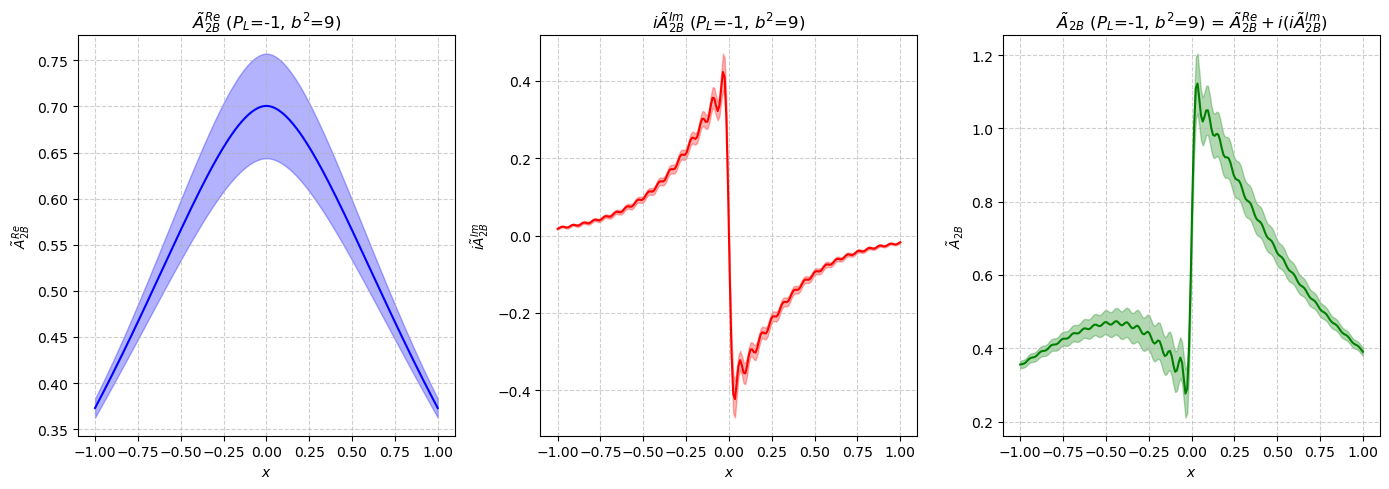

In [6]:
results_4 = FitSimultaneousA2B(PL=-1, bminForFit=3, etamin=6, etamax=10)
fig4, axes4 = plot_fourier_transforms(results_4, b2=9, PL=-1)


Simultaneous Fit (ReA2B & ImA2B) : PL=-2, b_min>=3, eta in [6, 10] ---

--- Fit Functions ---
def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, g, f, j):
    denom = (1 + (d + c) * bL**2 + d * bT**2)**j
    return a * gv.tanh(g*bL) * gv.exp(-f * eta) / denom

---------------------

Re A2B points: 225, Im A2B points: 175
Covariance Matrix size: (400, 400)


  0%|          | 0/2903 [00:00<?, ?it/s]


--- Final Extracted Parameters ---
k1_re = -3.9979(5747)
k2_re = -4.0999(2339)
    f = 0.4779(0103)
 a_re = 2.3557(1925)
 c_re = 0.2720(0847)
 d_re = 0.0648(0089)
 j_re = 2.4811(1667)
 a_im = 0.3399(0145)
 c_im = 0.5170(0108)
 d_im = 0.1831(0094)
 g_im = 0.3009(0121)
 j_im = 0.4299(0263)

 chi^2/dof : 1.7673(1287)

Evaluating Fourier transforms numerically and applying Jackknife...


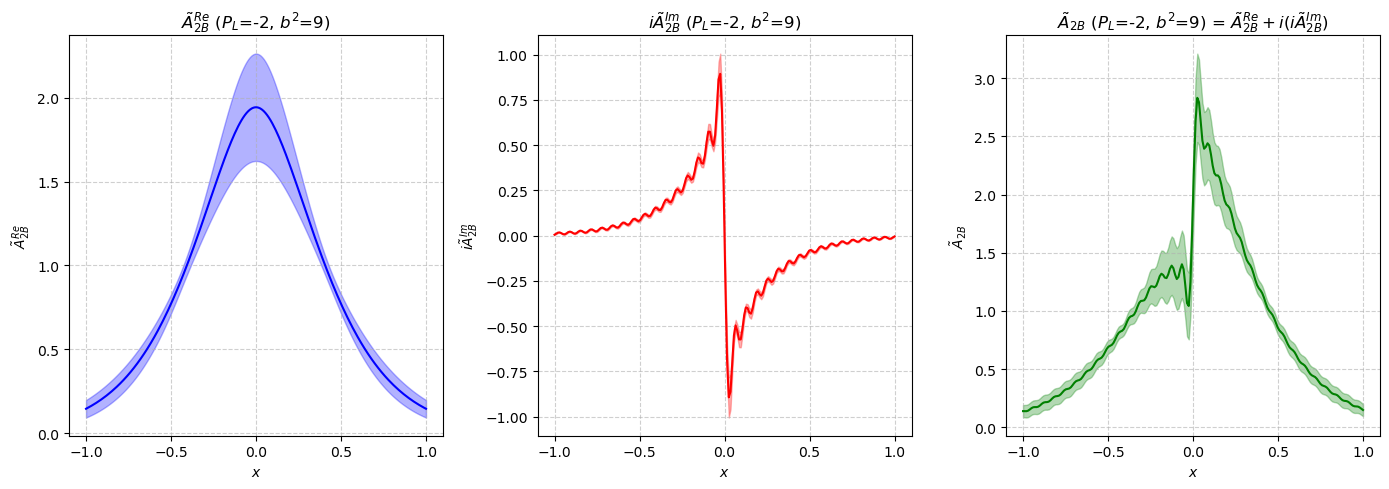

In [7]:
results_4 = FitSimultaneousA2B(PL=-2, bminForFit=3, etamin=6, etamax=10)
fig4, axes4 = plot_fourier_transforms(results_4, b2=9, PL=-2)


Simultaneous Fit (ReA2B & ImA2B) : PL=-3, b_min>=3, eta in [6, 10] ---

--- Fit Functions ---
def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta + k2/gv.sqrt(eta))) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, g, f, j):
    denom = (1 + (d + c) * bL**2 + d * bT**2)**j
    return a * gv.tanh(g*bL) * gv.exp(-f * eta) / denom

---------------------

Re A2B points: 225, Im A2B points: 175
Covariance Matrix size: (400, 400)


  0%|          | 0/2903 [00:00<?, ?it/s]


--- Final Extracted Parameters ---
k1_re = -5.4463(3568)
k2_re = -4.6831(1500)
    f = 0.4562(0203)
 a_re = 1.7355(2700)
 c_re = 0.8087(2183)
 d_re = 0.0647(0107)
 j_re = 2.7669(1604)
 a_im = 0.2422(0140)
 c_im = 0.5815(0034)
 d_im = 0.0957(0117)
 g_im = 0.2556(0147)
 j_im = 0.4091(0484)

 chi^2/dof : 0.8816(0904)

Evaluating Fourier transforms numerically and applying Jackknife...


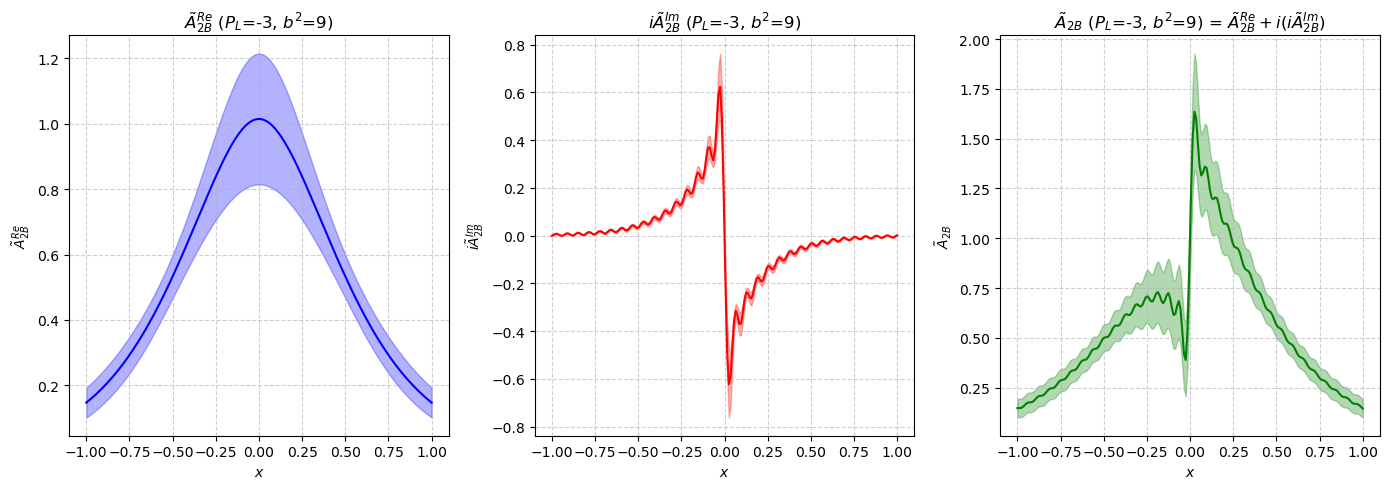

In [2]:
results_4 = FitSimultaneousA2B(PL=-3, bminForFit=3, etamin=6, etamax=10)
fig4, axes4 = plot_fourier_transforms(results_4, b2=9, PL=-3)
